# Keypoint Corrections

1. Smoothen foot/ankle keypoints
2. Correct hip keypoints

## 1. Smoothen foot/ankle keypoints

Using Savitzky–Golay filter

In [1]:
import os
from pathlib import Path
import pandas as pd
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
import glob
import numpy as np

UP_DIR = Path('../data/processed/keypoints_combined')
DOWN_DIR = Path('../data/processed/keypoints_combined_down')

SAVGOY_LANDMARKS = [
  'left_ankle_x', 'left_ankle_y', 'right_ankle_x', 'right_ankle_y',
  'left_heel_x', 'left_heel_y', 'right_heel_x', 'right_heel_y',
  'left_foot_index_x', 'left_foot_index_y', 'right_foot_index_x', 'right_foot_index_y'
]

UP_TIME_DICT = {
  '028': (9.90, 10.40, 10.50, 11.12, 11.19, 11.77),
  '030': (5.80, 6.25, 6.32,  6.70,  6.76,  7.63),
  '045': (6.54, 6.70, 6.70,  7.29,  7.45,  7.98),
  '047': (7.03, 7.41, 7.49,  7.79,  7.97,  8.91),
  '059': (6.65, 6.88, 6.90,  7.96,  8.19,  9.11),
  '061': (7.00, 7.40, 7.45,  8.10,  8.20,  9.00),
  '074': (6.07, 6.33, 6.35,  6.71,  6.90,  7.27),
  '076': (5.20, 5.80, 5.90,  6.30,  6.40,  7.30),
  '091': (6.39, 6.55, 6.60,  7.03,  7.18,  7.61),
  '093': (5.86, 6.10, 6.20,  6.65,  6.85,  7.67),
}

DOWN_TIME_DICT = {
  '028': (11.87, 11.90, 11.90, 12.57, 12.82),
  '030': (8.07, 9.62, 9.62, 10.64, 11.16),
  '045': (7.94, 7.96, 7.96, 8.74, 9.26),
  '047': (9.20, 10.14, 10.14, 11.10, 11.70),
  '059': (9.11, 9.18, 9.18, 10.37, 11.06),
  '061': (10.57, 10.88, 10.88, 12.26, 13.00),
  '074': (7.27, 7.30, 7.30, 7.88, 8.14),
  '076': (8.27, 8.72, 8.72, 9.73, 10.32),
  '091': (7.56, 7.58, 7.58, 8.09, 8.18),
  '093': (8.50, 9.19, 9.19, 10.08, 10.74),
}

WINDOW_SIZE = 11
POLY_DEGREE = 3

In [2]:
sagvoy_dict = {}

for dir in [(UP_DIR, 'up'), (DOWN_DIR, 'down')]:
    out_dir = Path(str(dir[0]).replace('combined', 'corrected'))
    out_dir.mkdir(parents=True, exist_ok=True)
    direction_dict = {}
    for file in dir[0].iterdir():
        data = pd.read_csv(file)
        time_data = data['time']
        foot_data = data[SAVGOY_LANDMARKS]
        smoothened_foot_data = savgol_filter(foot_data, WINDOW_SIZE, POLY_DEGREE, axis=0)
        smoothened_df = pd.DataFrame(smoothened_foot_data, columns=SAVGOY_LANDMARKS)

        video_dict = {
            'time': time_data,
            'original': foot_data,
            'smooth': smoothened_df
        }
        direction_dict[file.stem] = video_dict

        data[smoothened_df.columns] = smoothened_df
        data.to_csv(out_dir / file.name, index=None)
    sagvoy_dict[dir[1]] = direction_dict

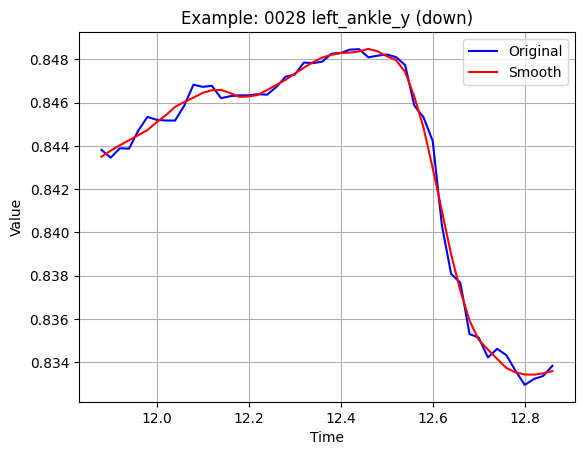

In [3]:
landmark = 'left_ankle_y'
direction = 'down'
video = 'DJI_20250425092743_0028_D'

original_path = DOWN_DIR if direction == 'down' else UP_DIR
original_path = original_path / f'{video}.csv'
smooth_path = Path(str(original_path).replace('combined', 'corrected'))

original = pd.read_csv(original_path)
time = original['time']
original = original[landmark]
smooth = pd.read_csv(smooth_path)[landmark]

plt.plot(time, original, label='Original', color='blue')
plt.plot(time, smooth, label='Smooth', color='red')
plt.grid()
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.title(f'Example: {video.split('_')[2]} {landmark} ({direction})')
plt.show()

## Angle plots

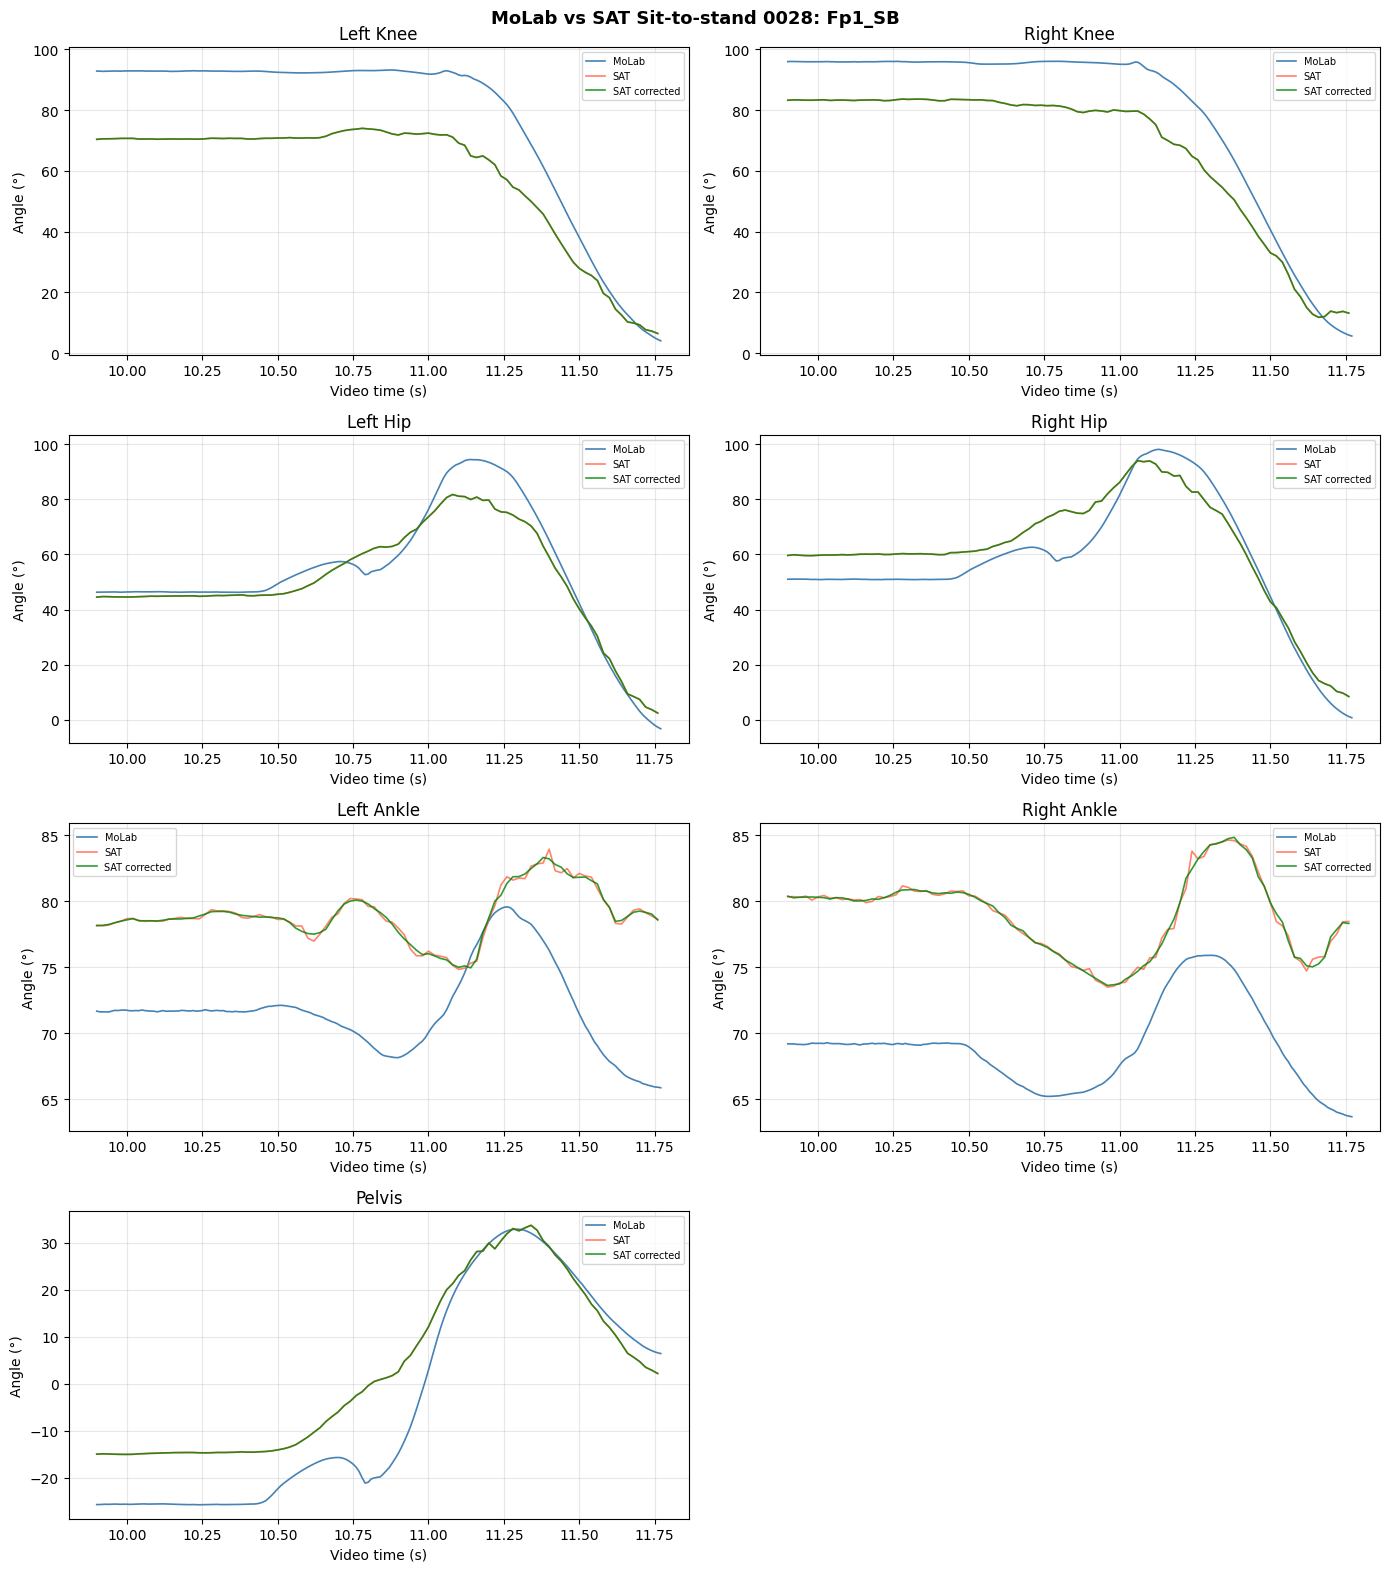

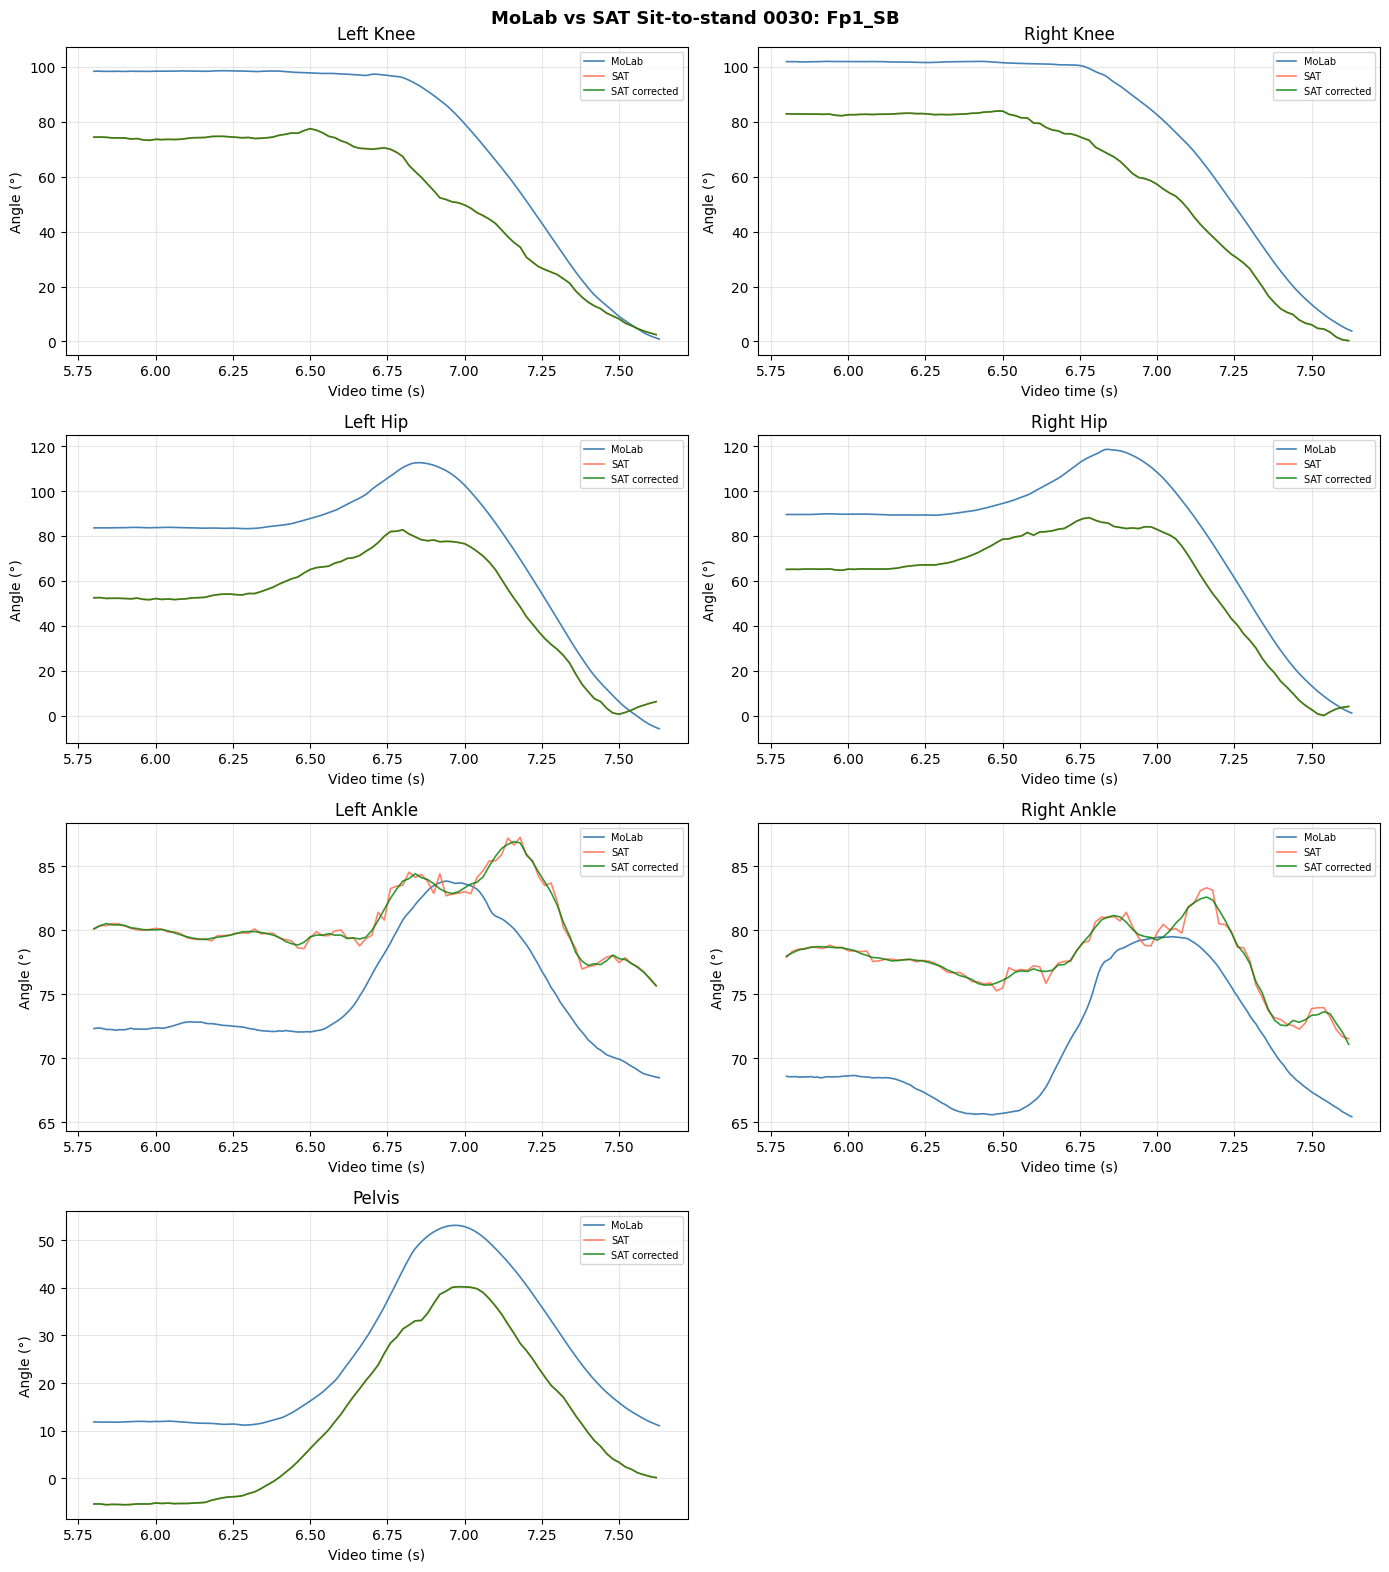

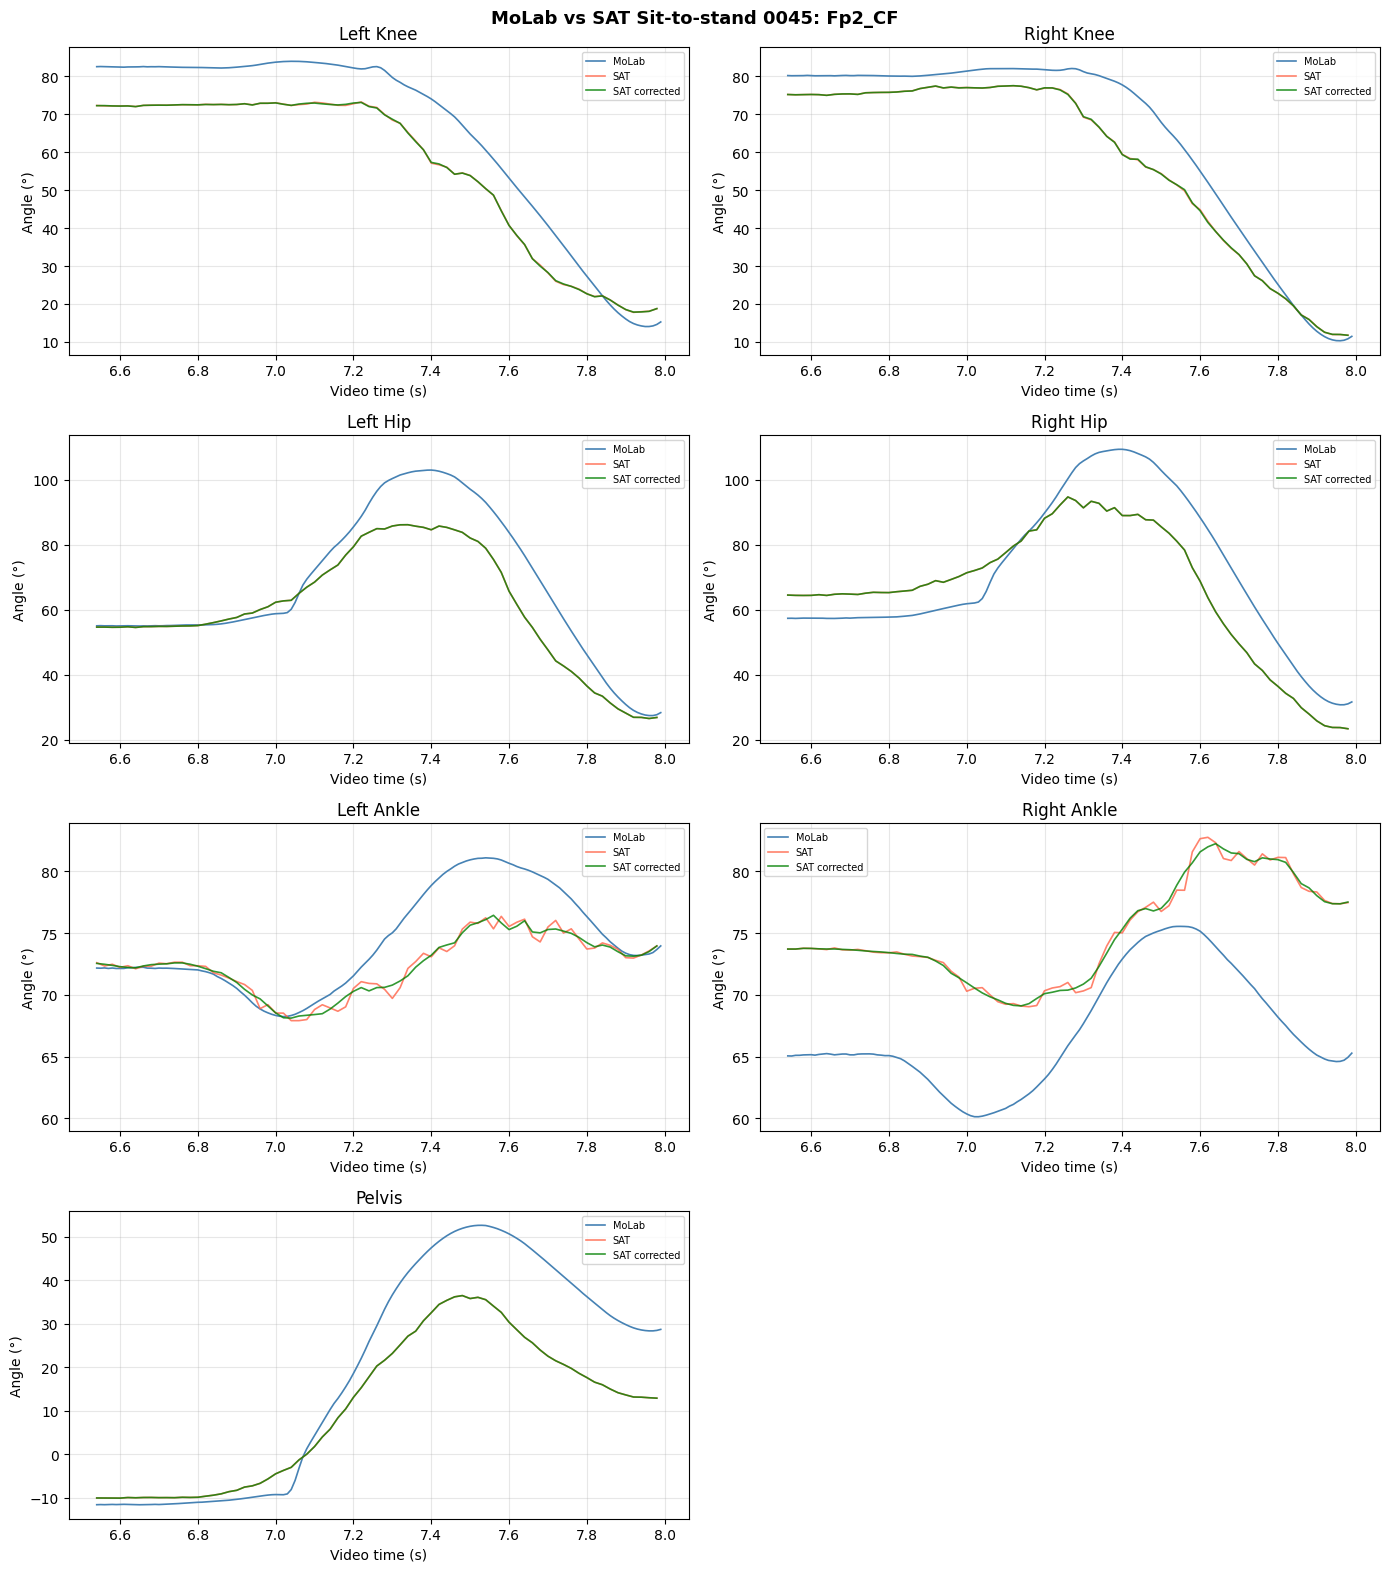

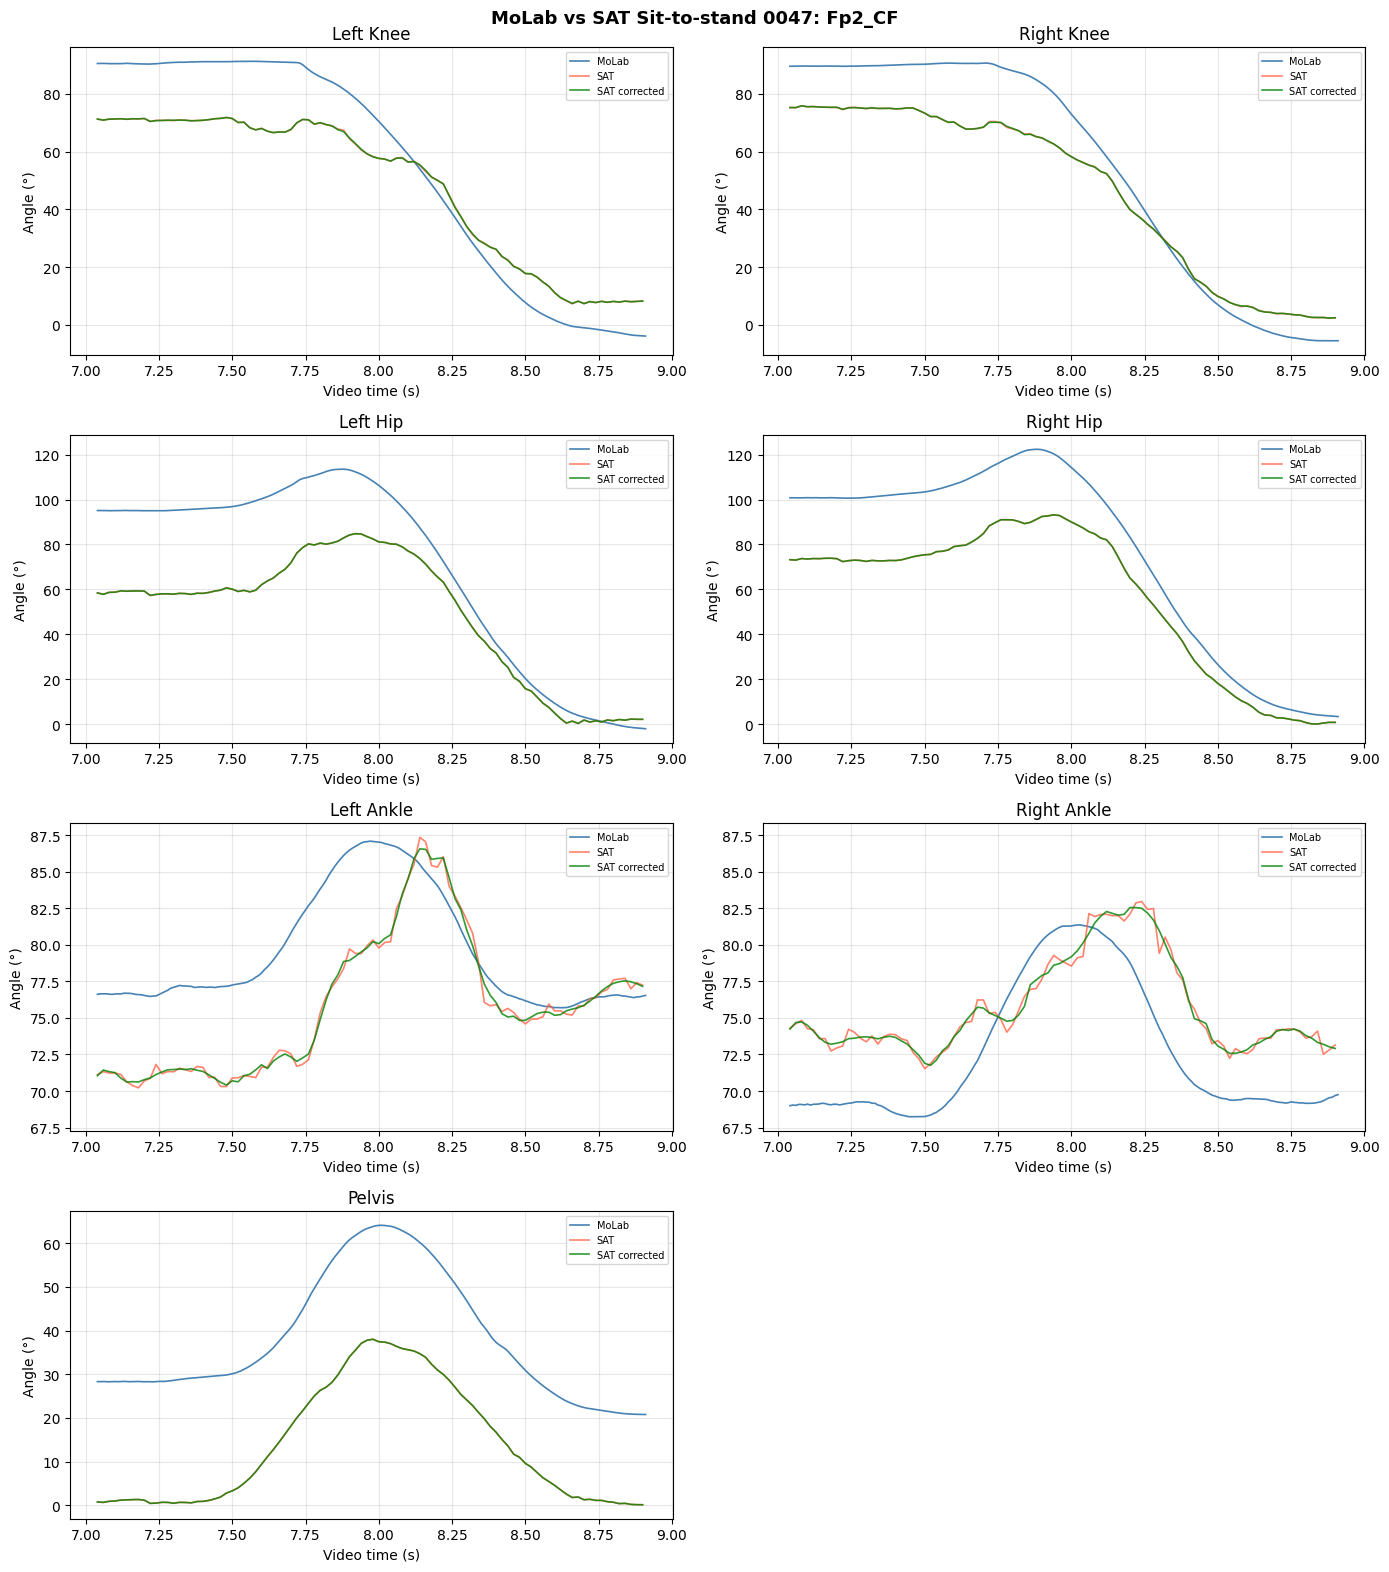

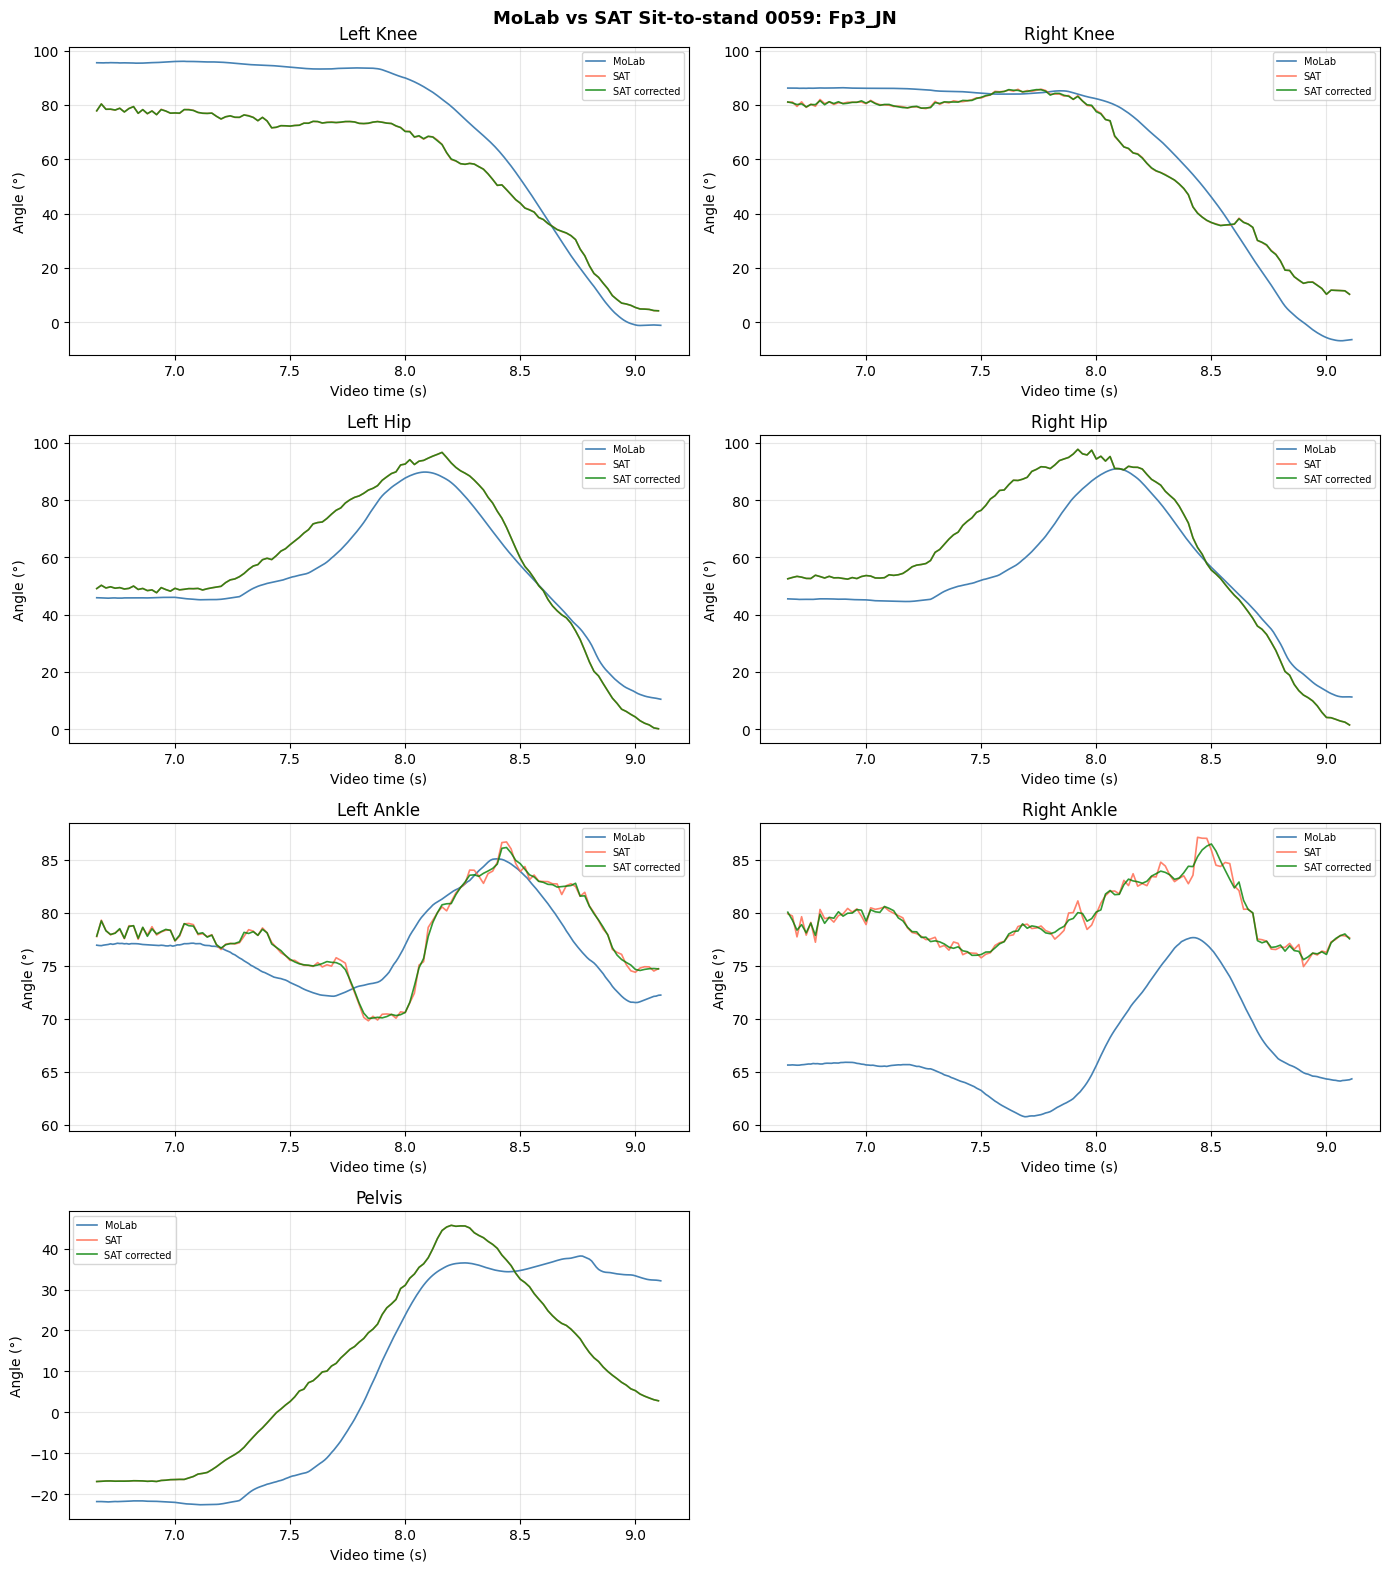

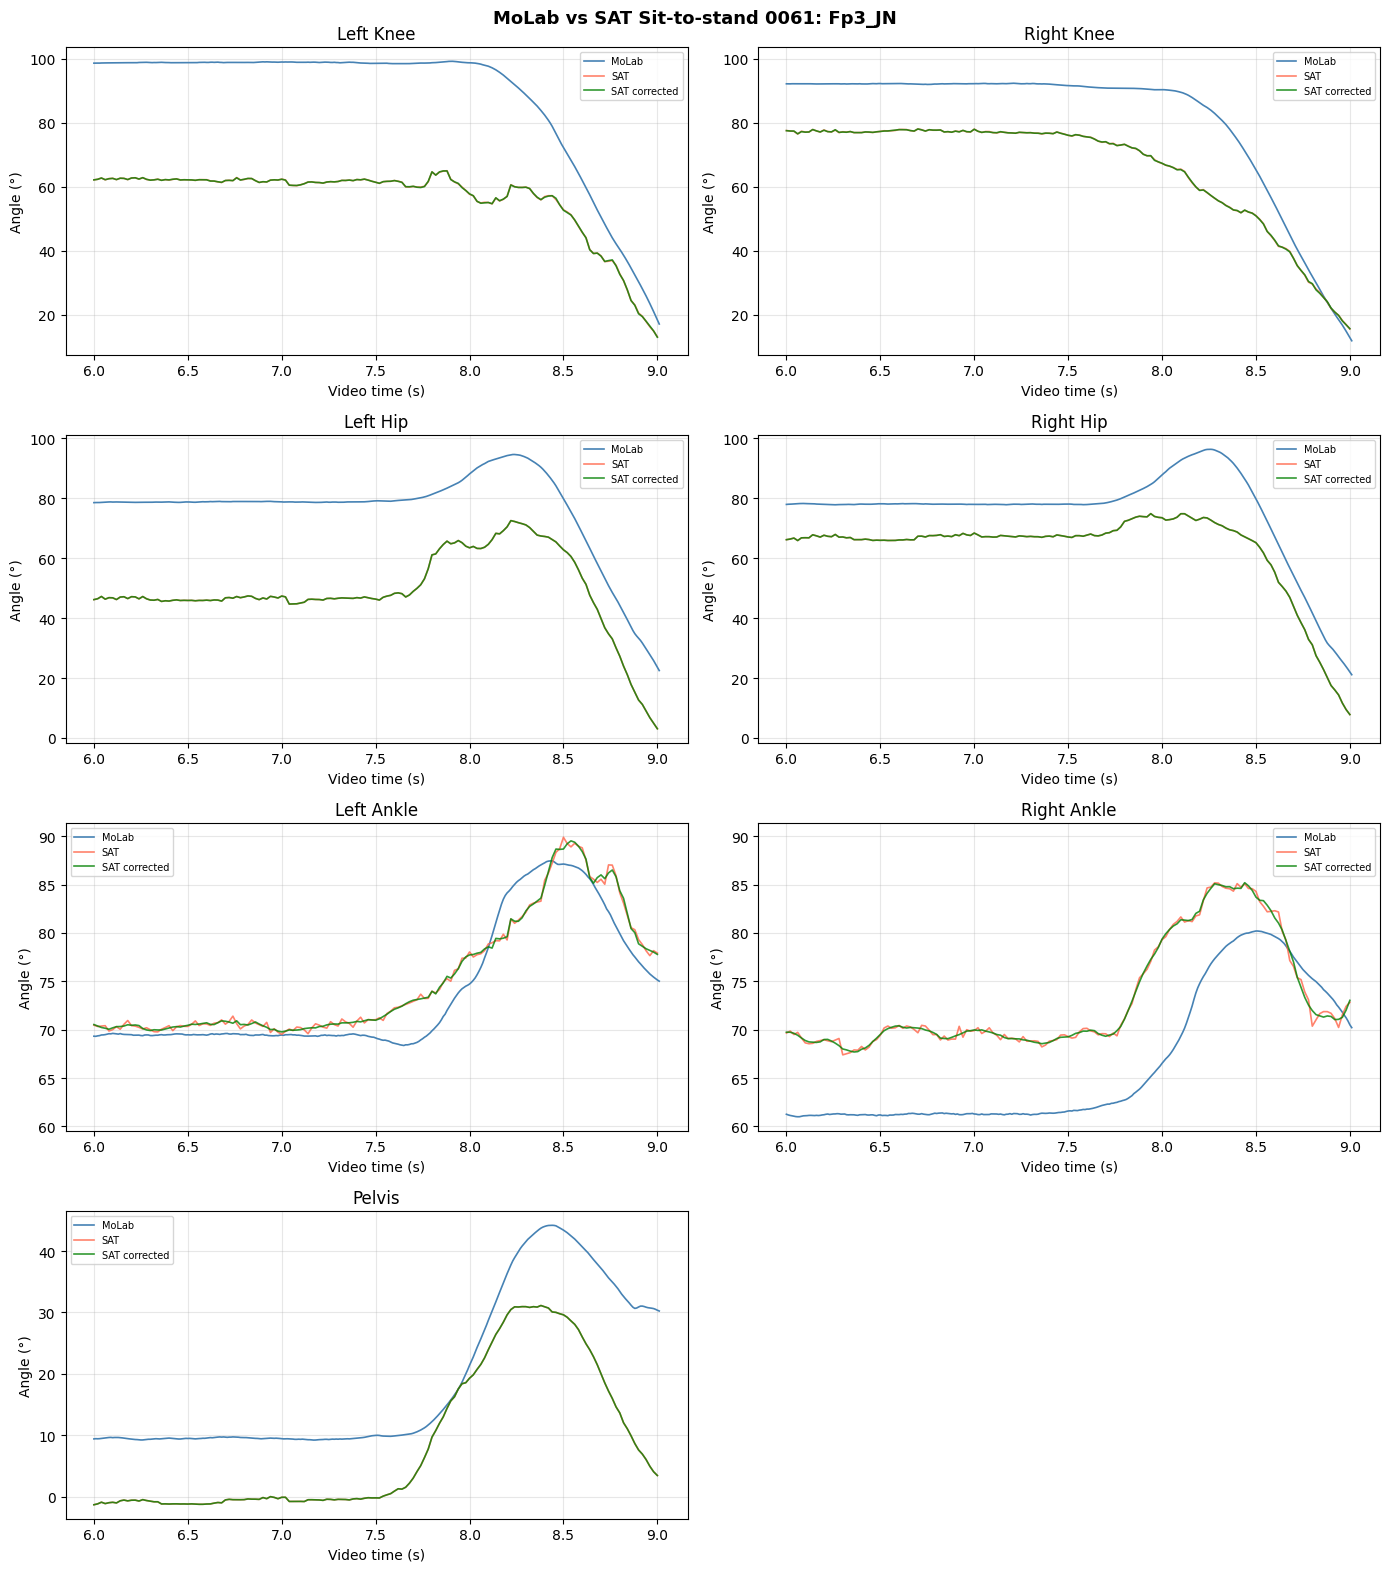

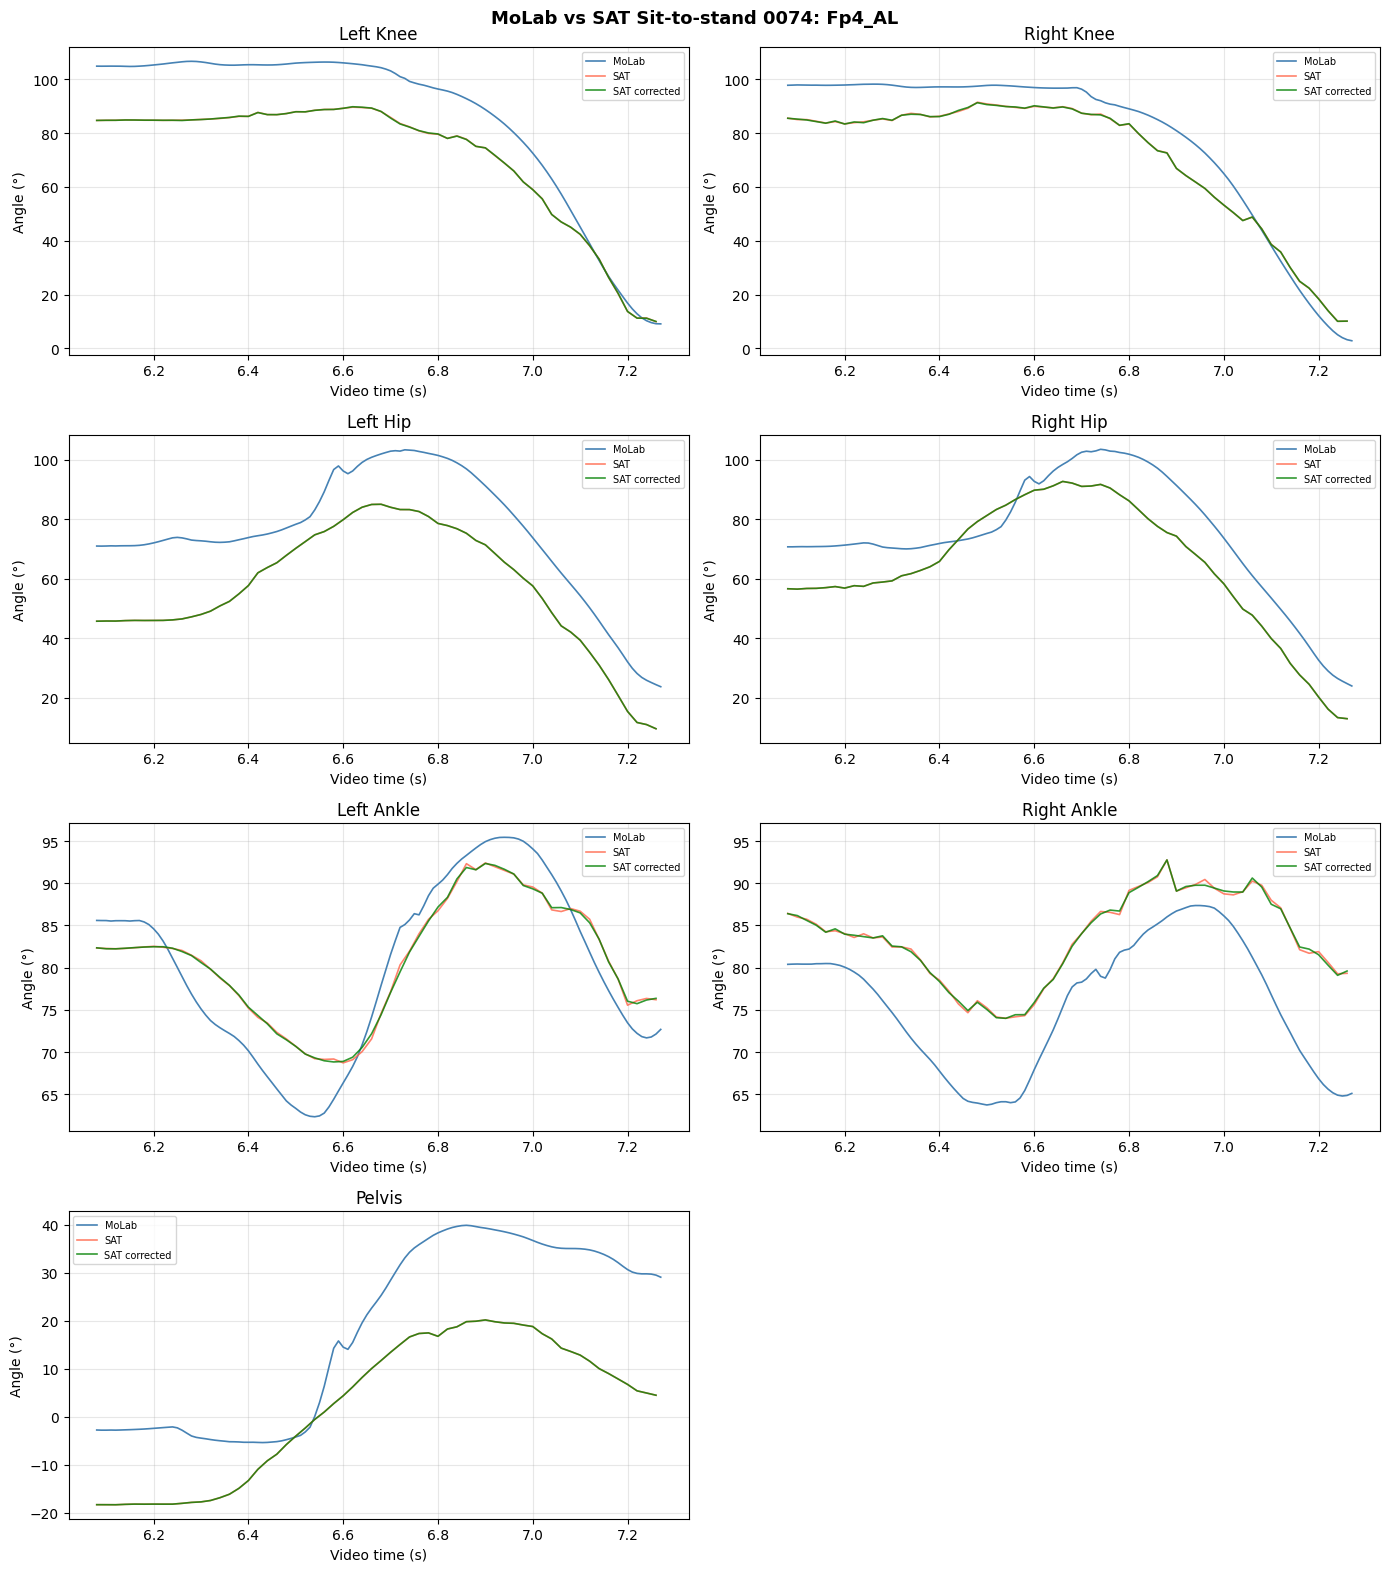

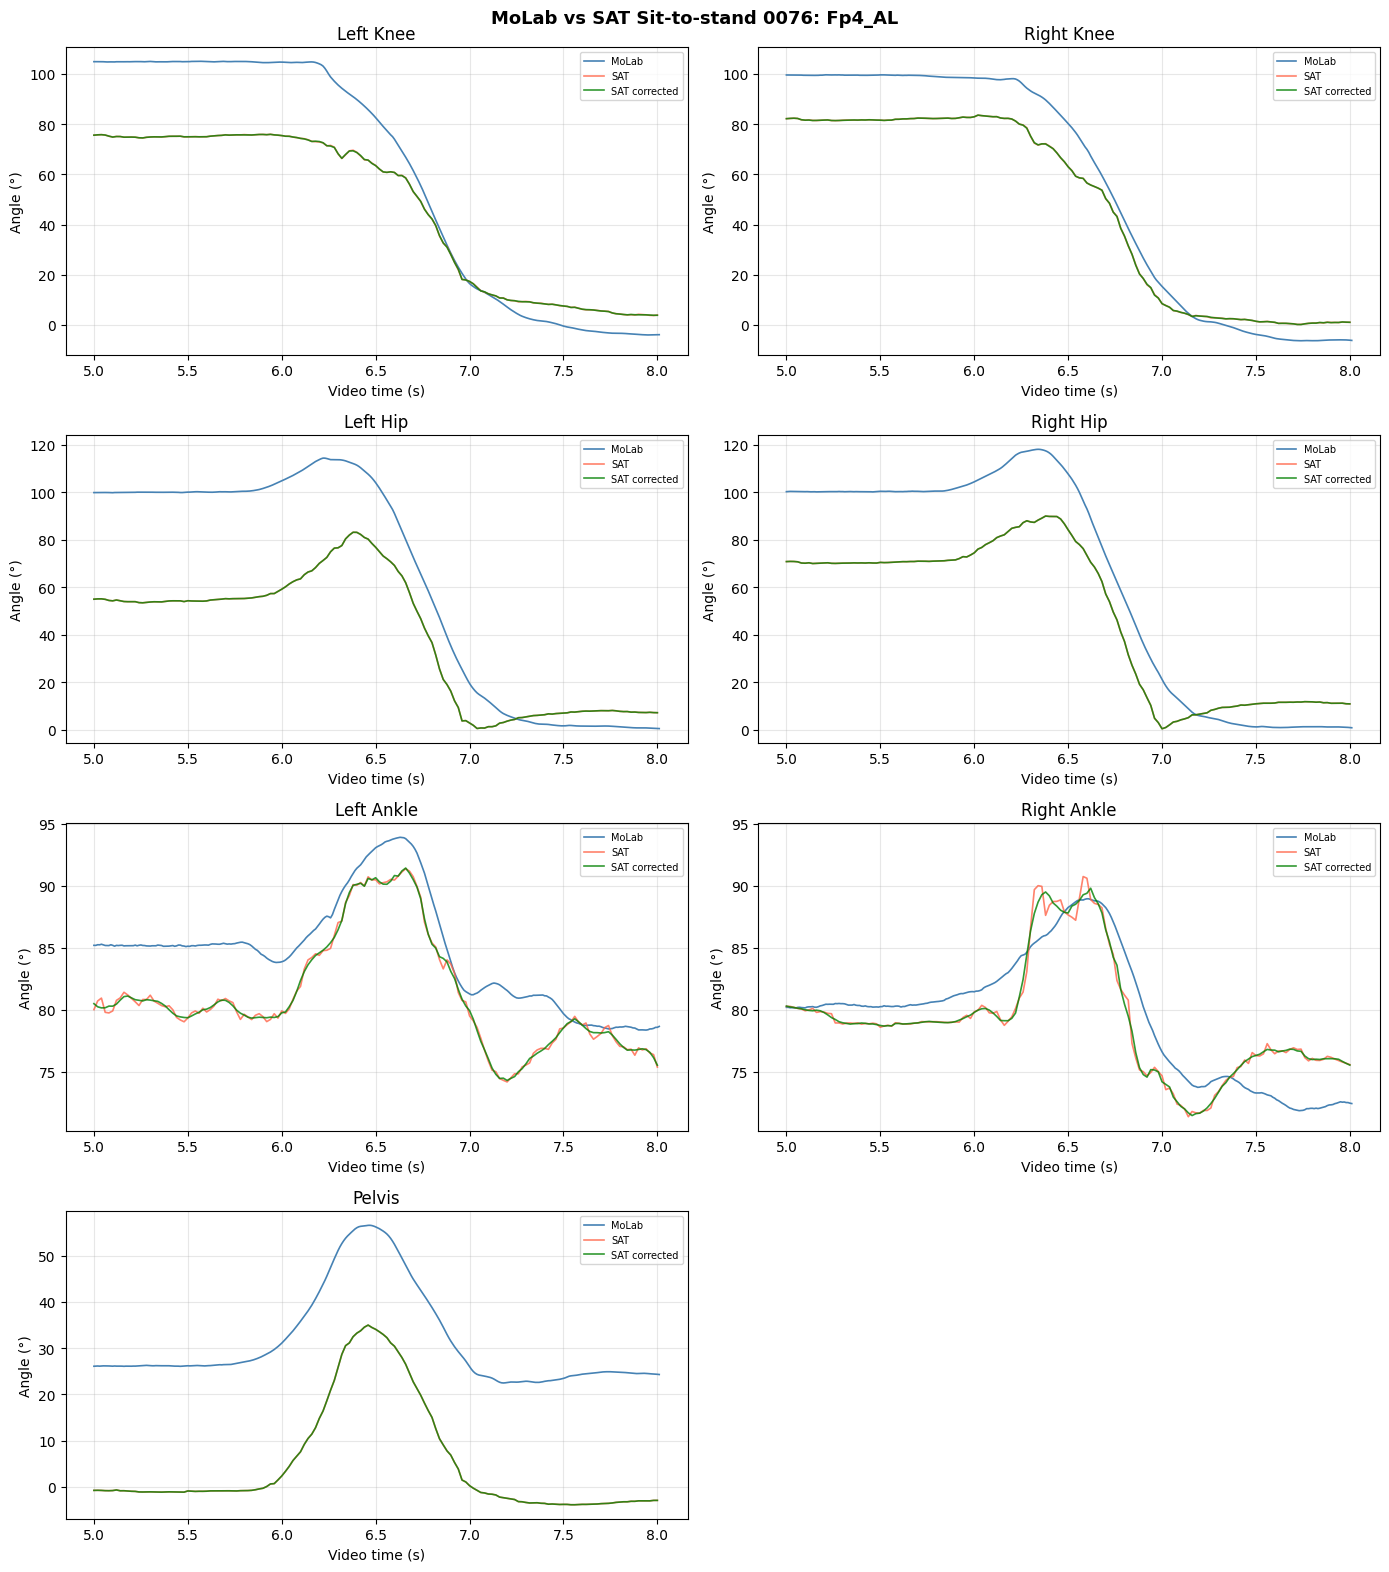

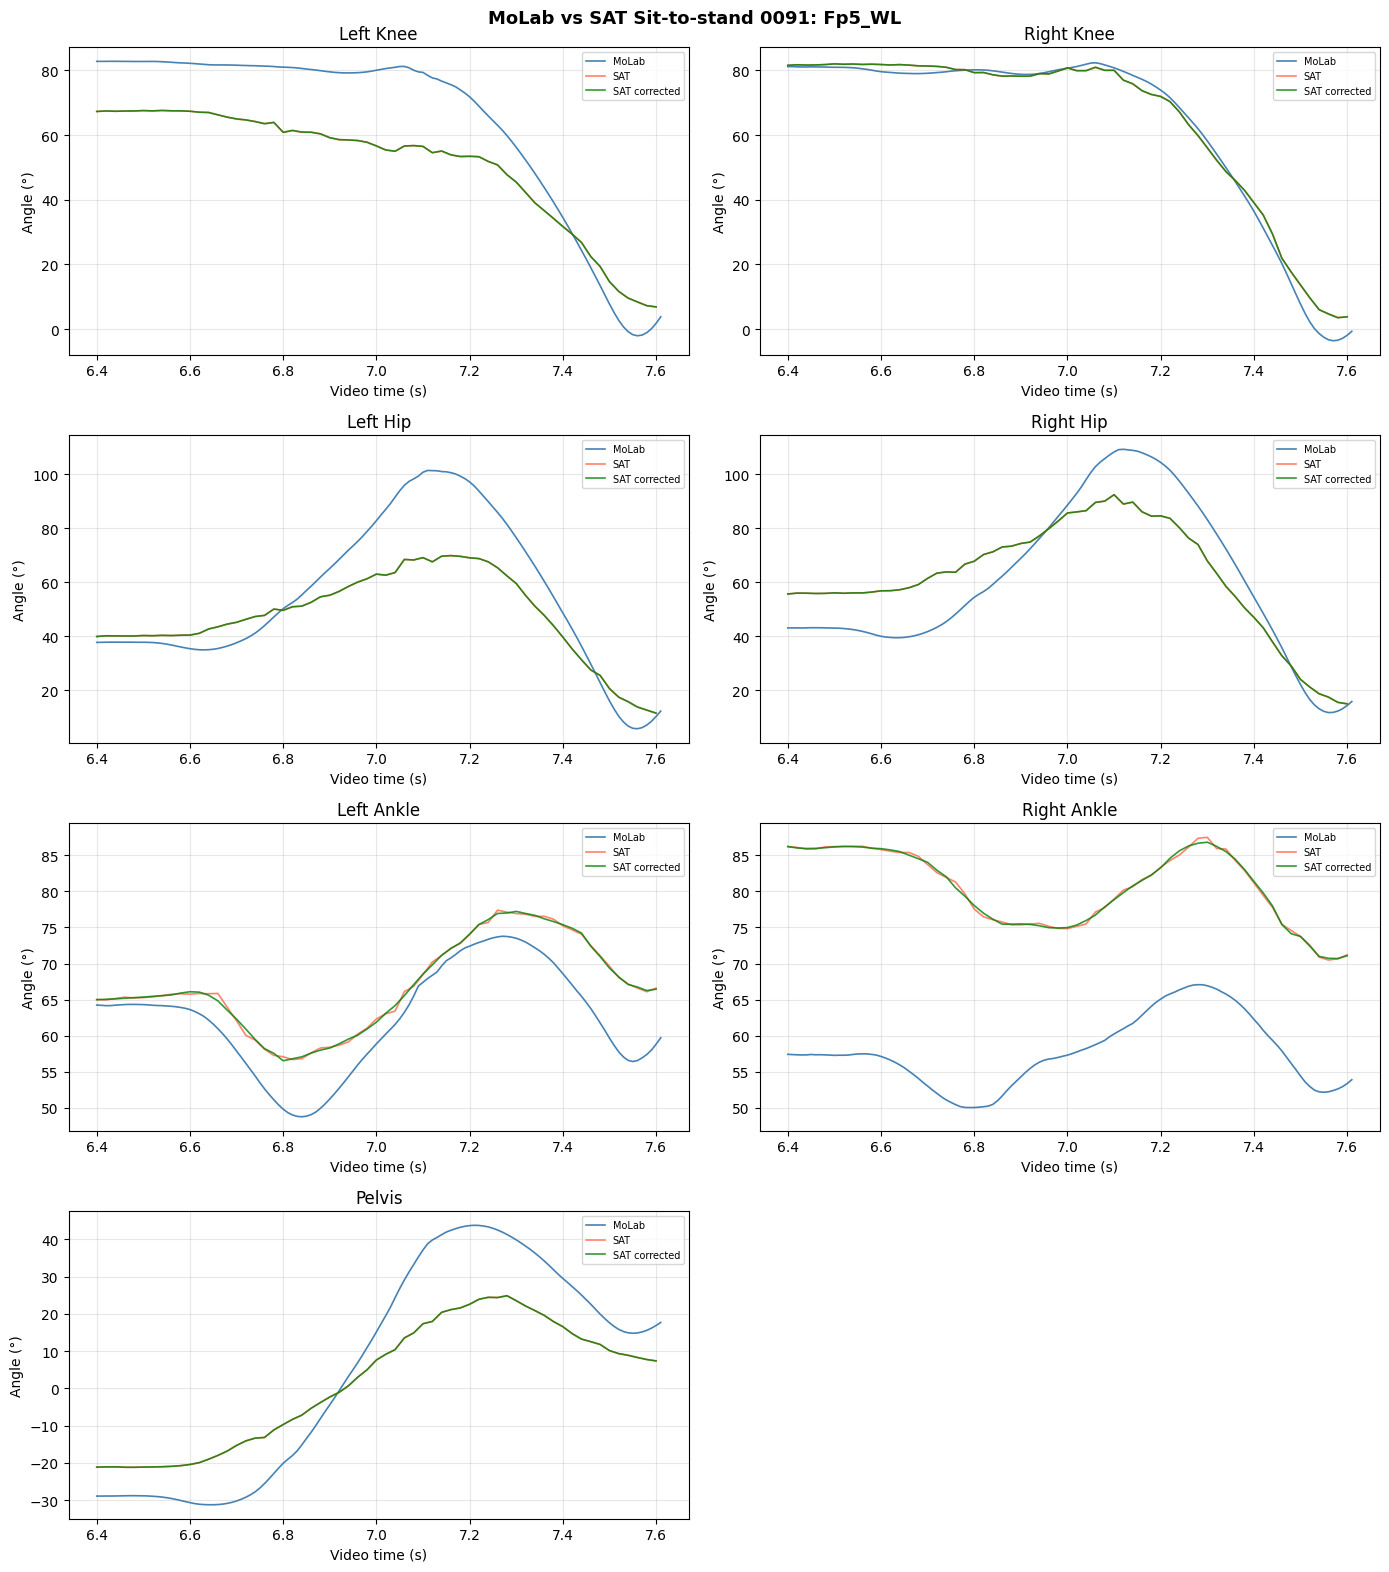

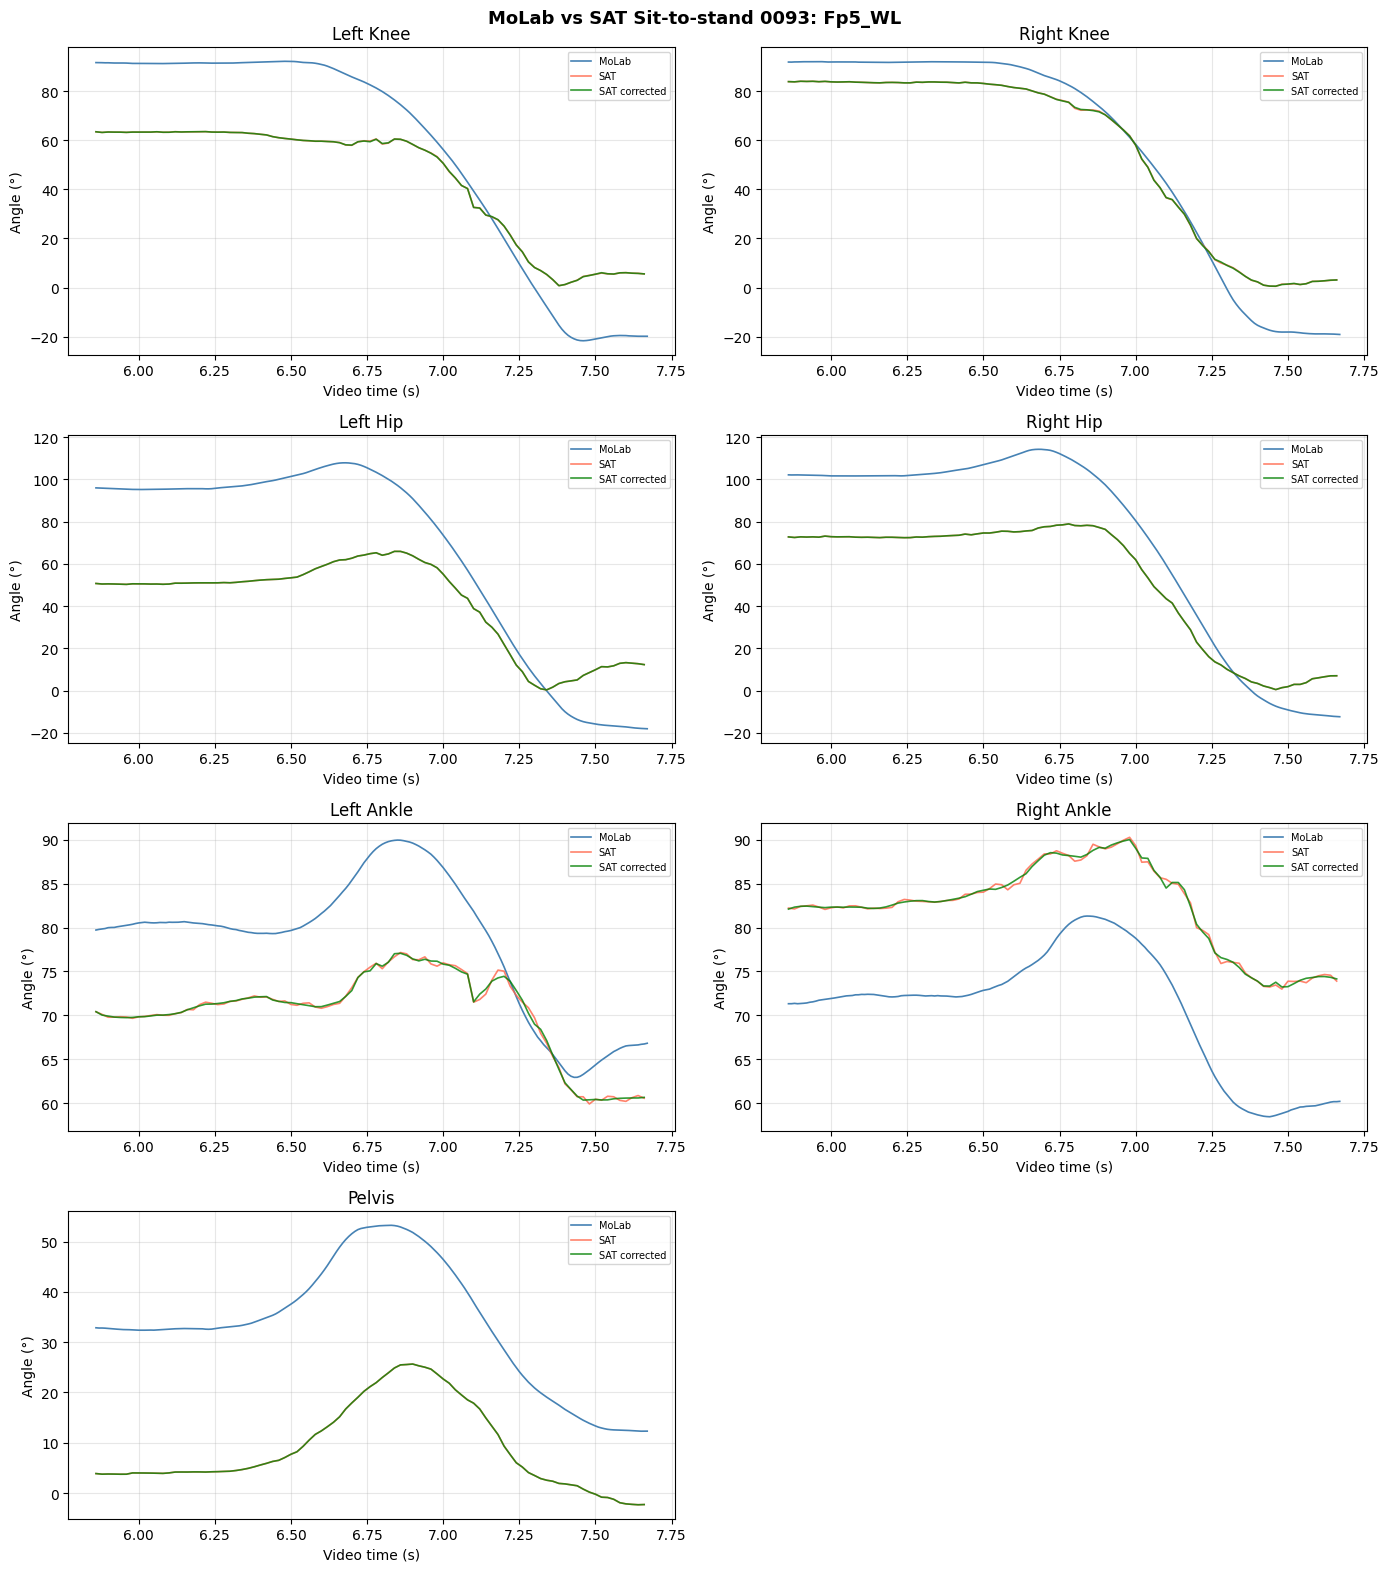

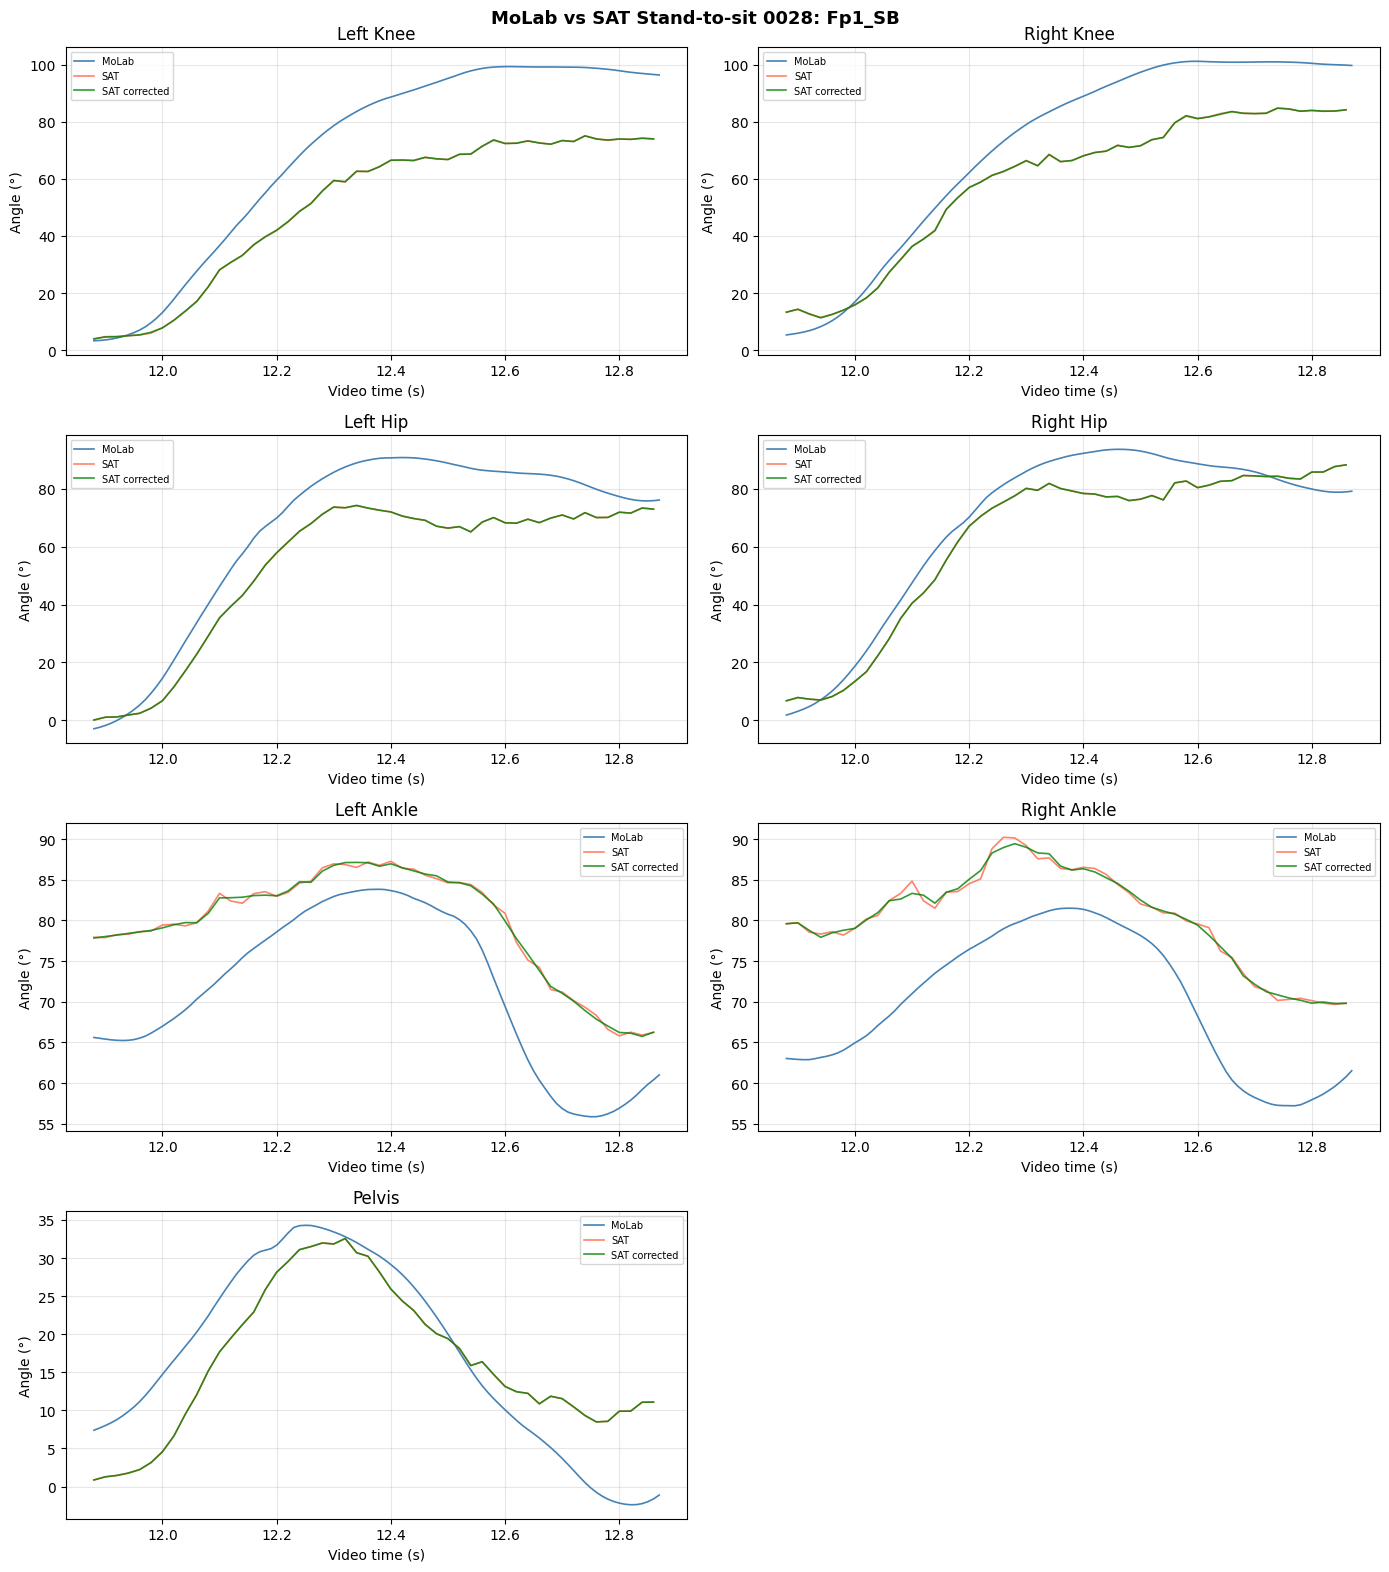

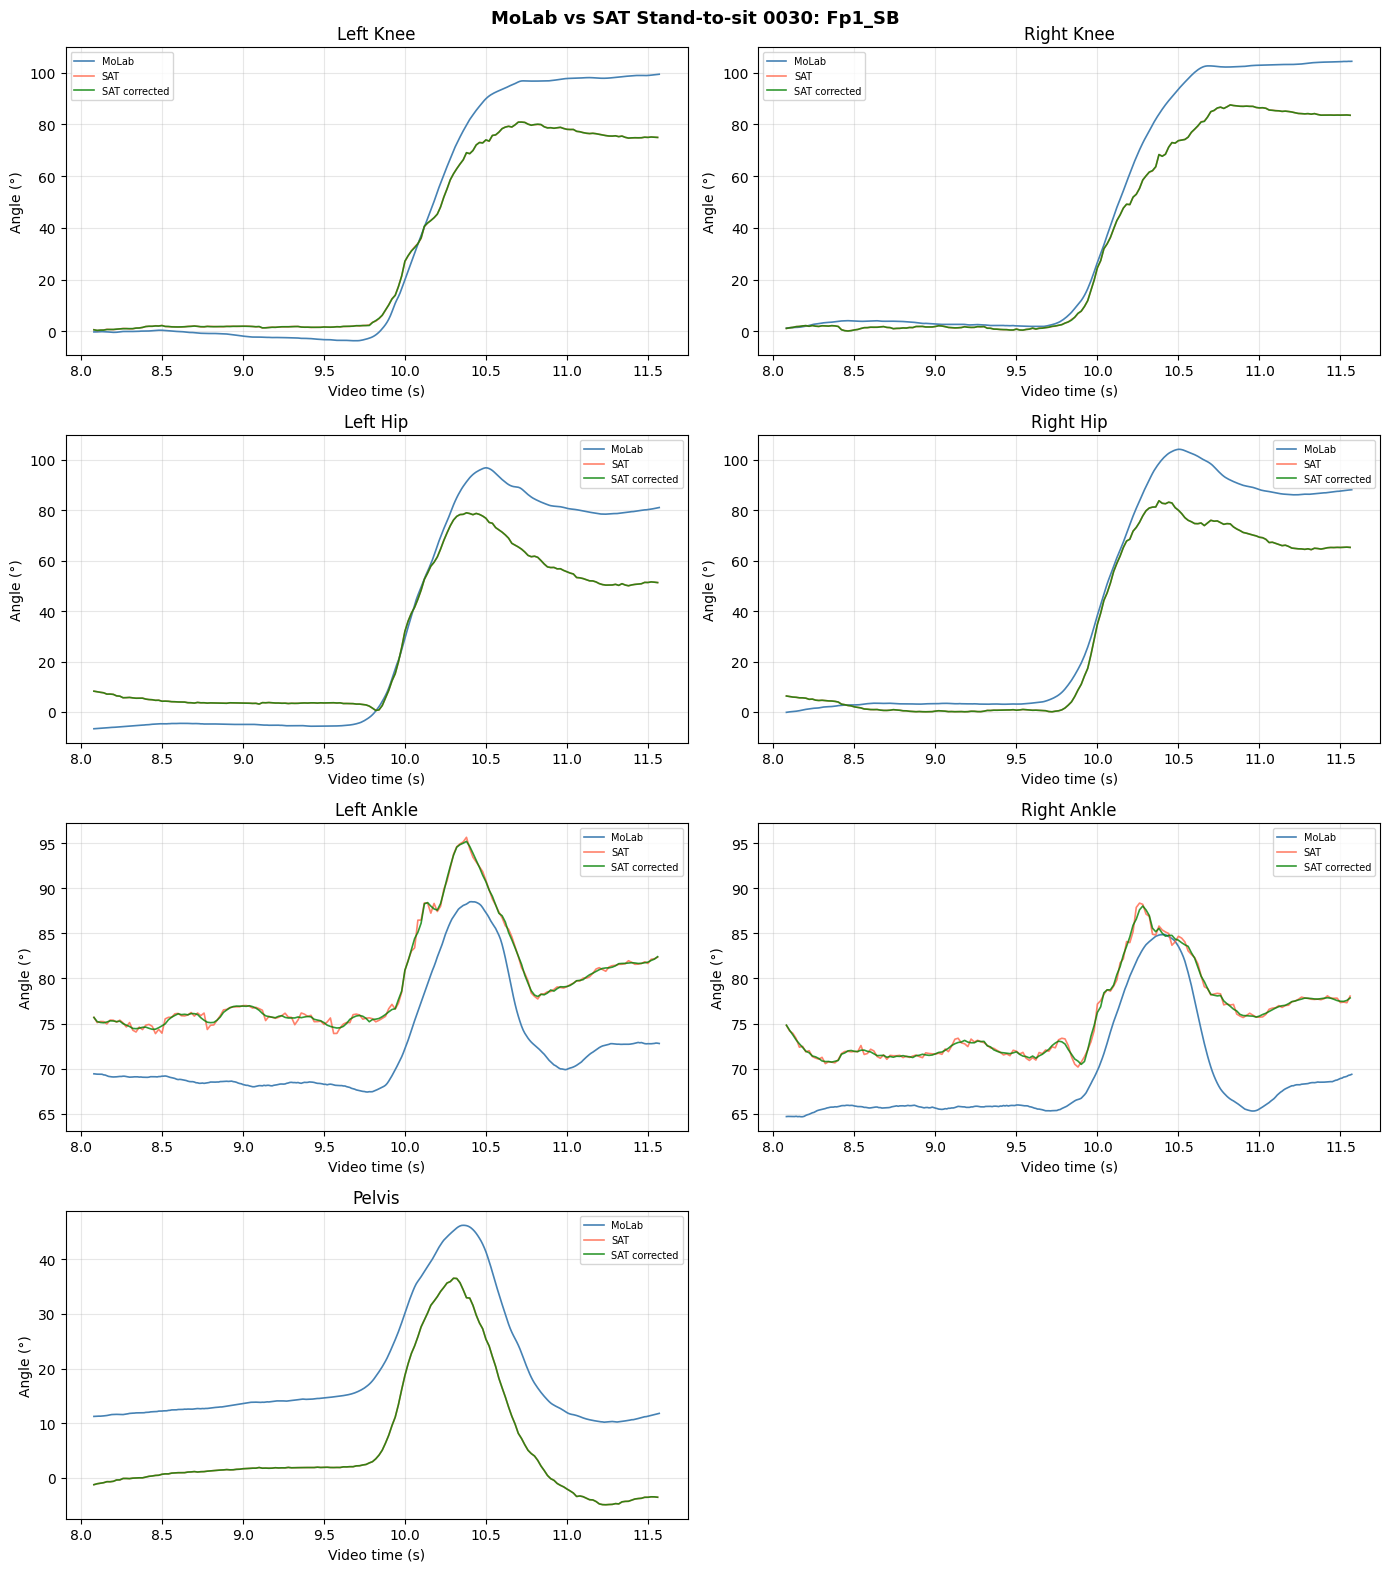

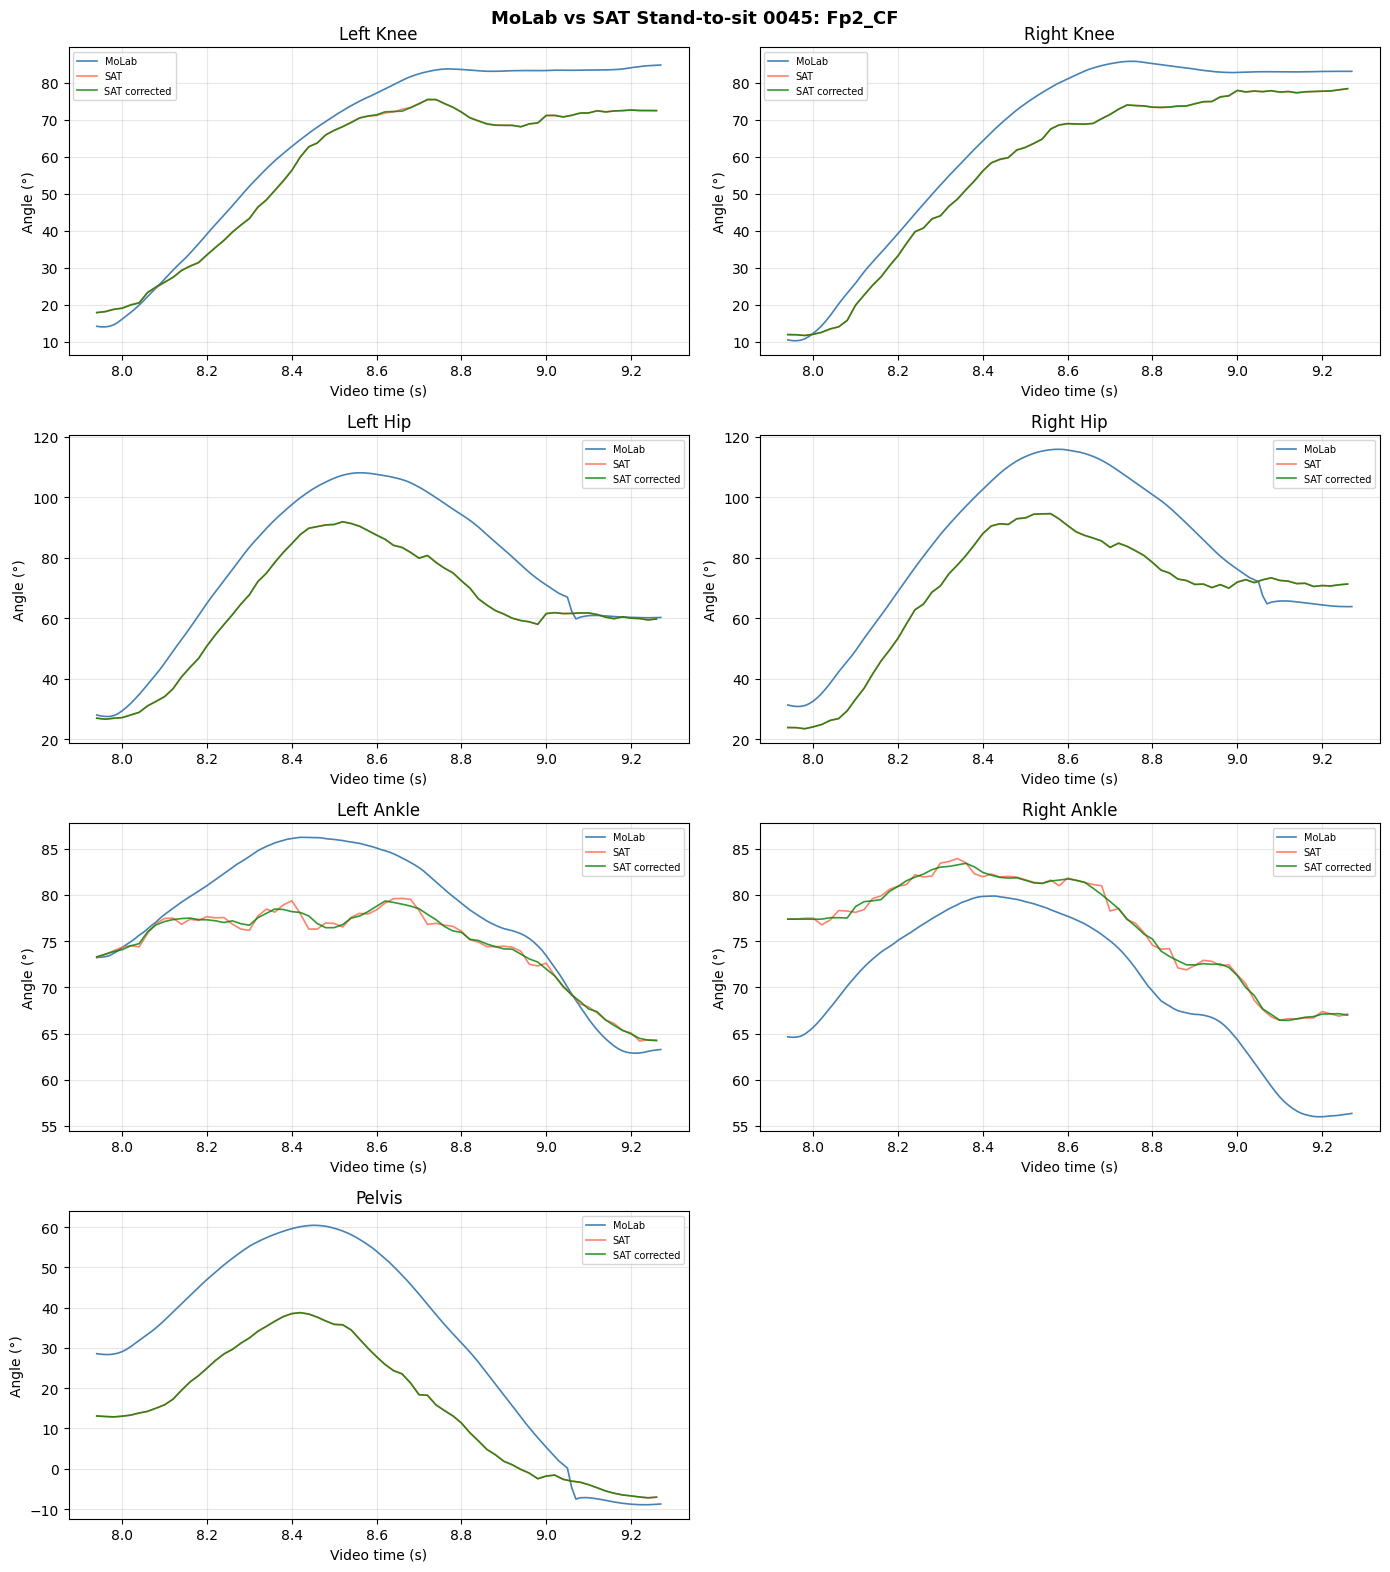

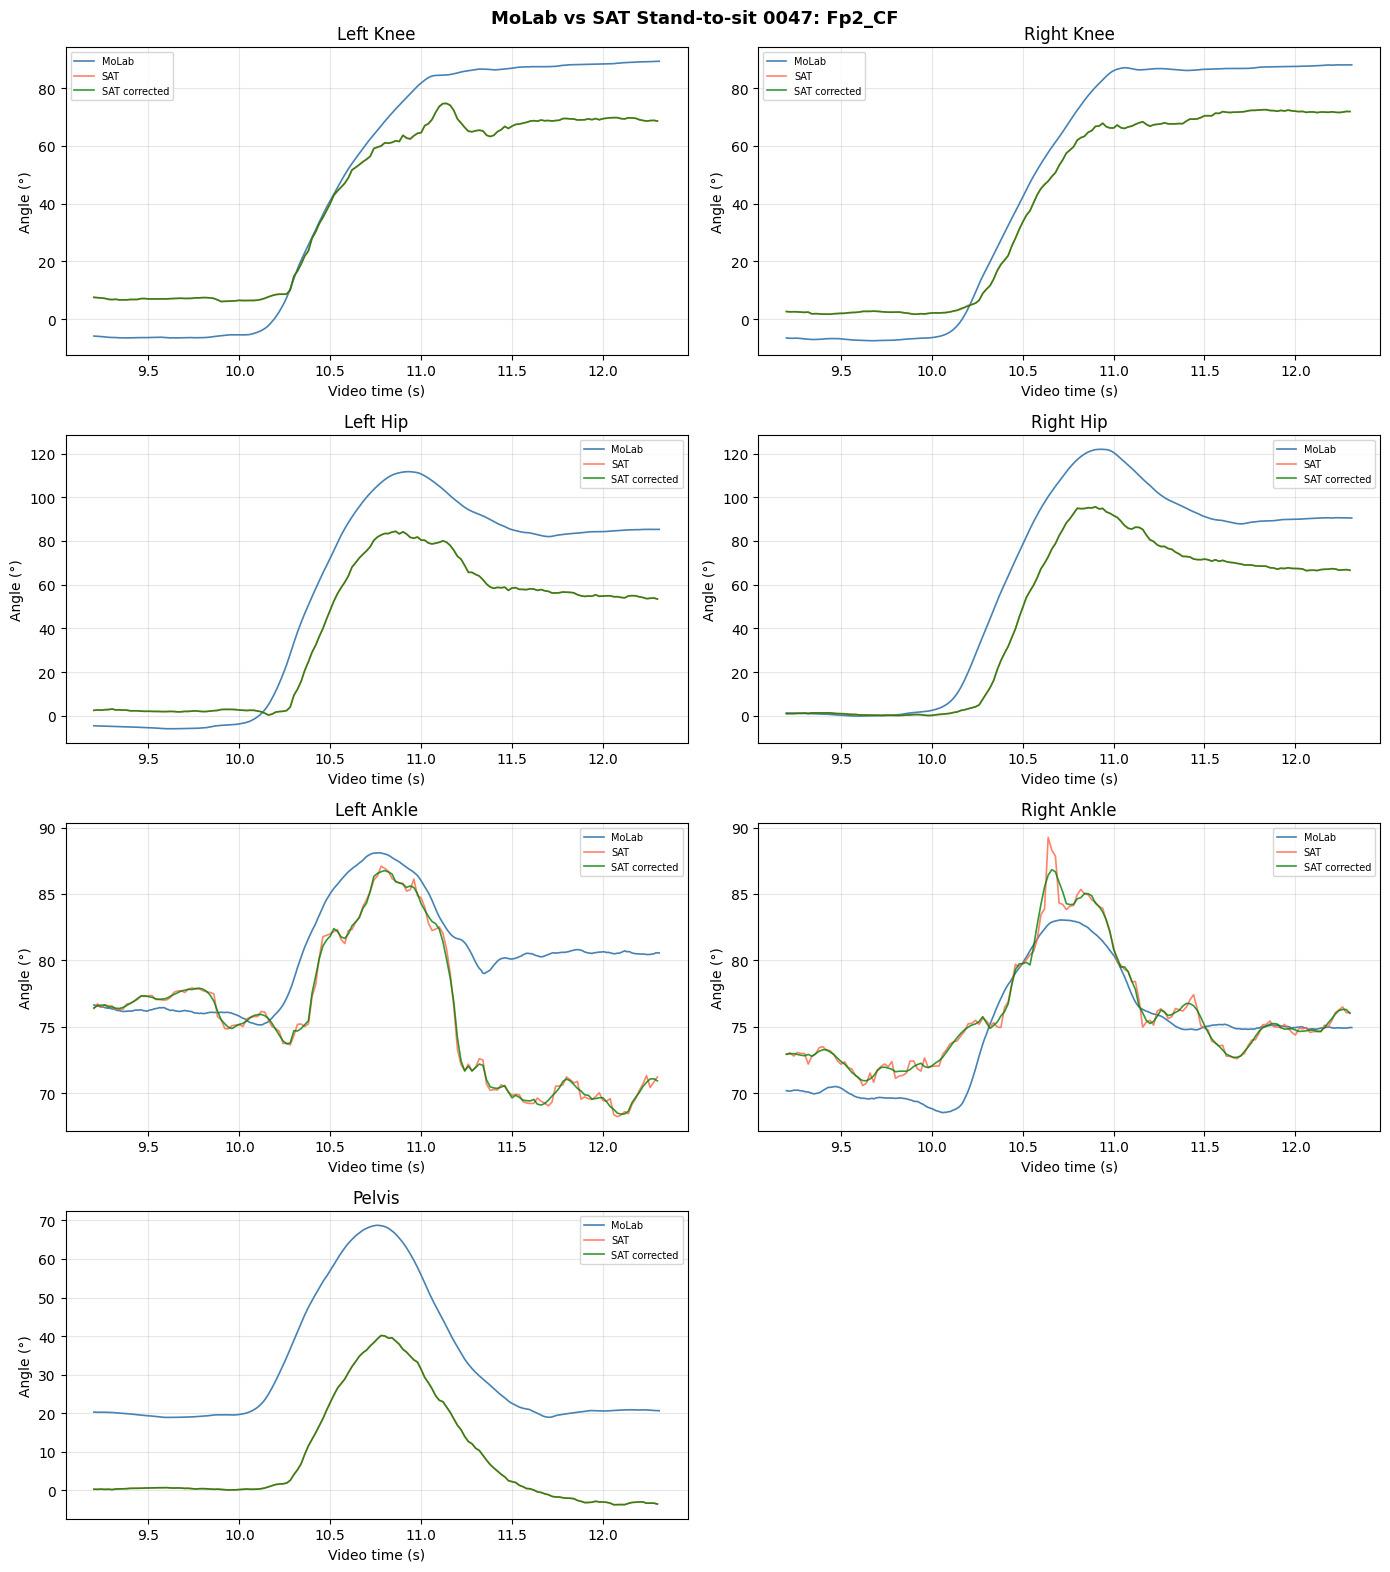

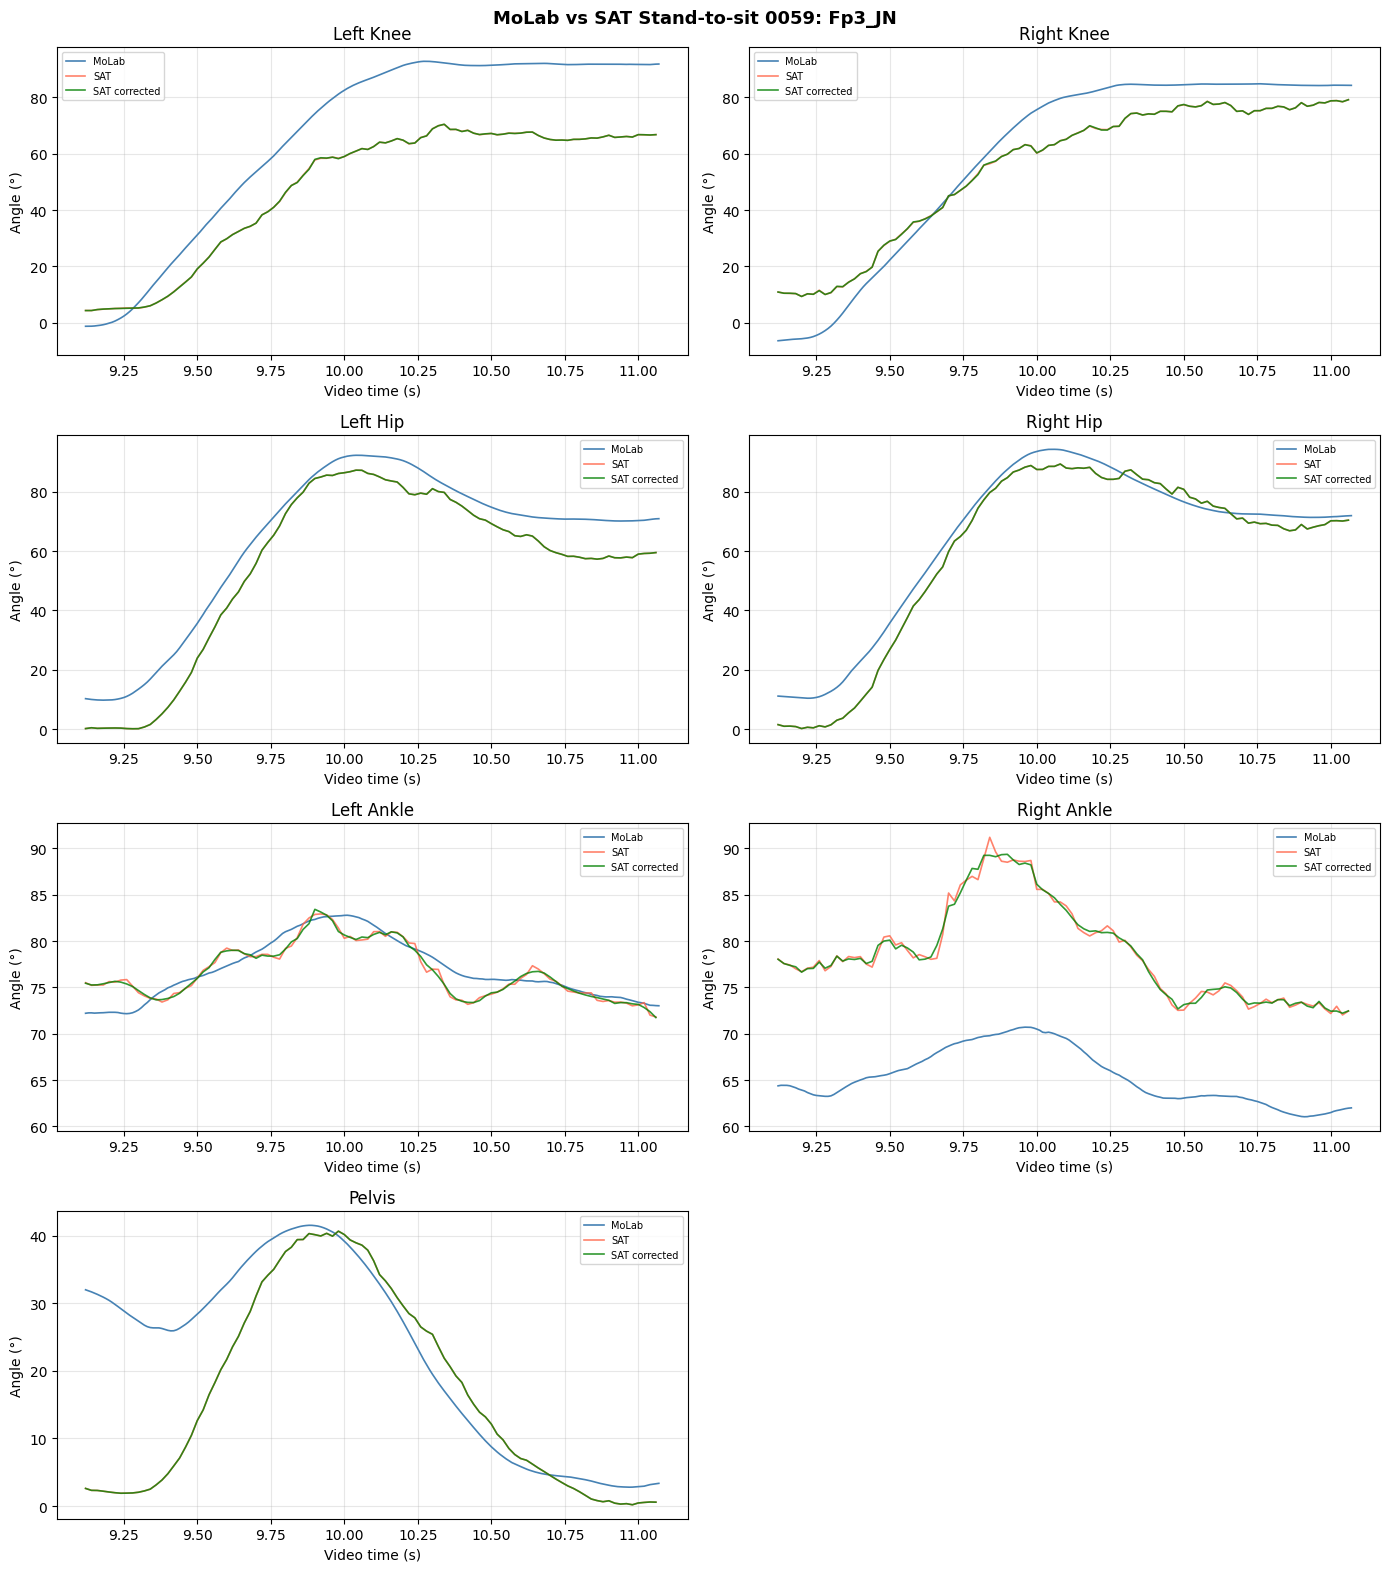

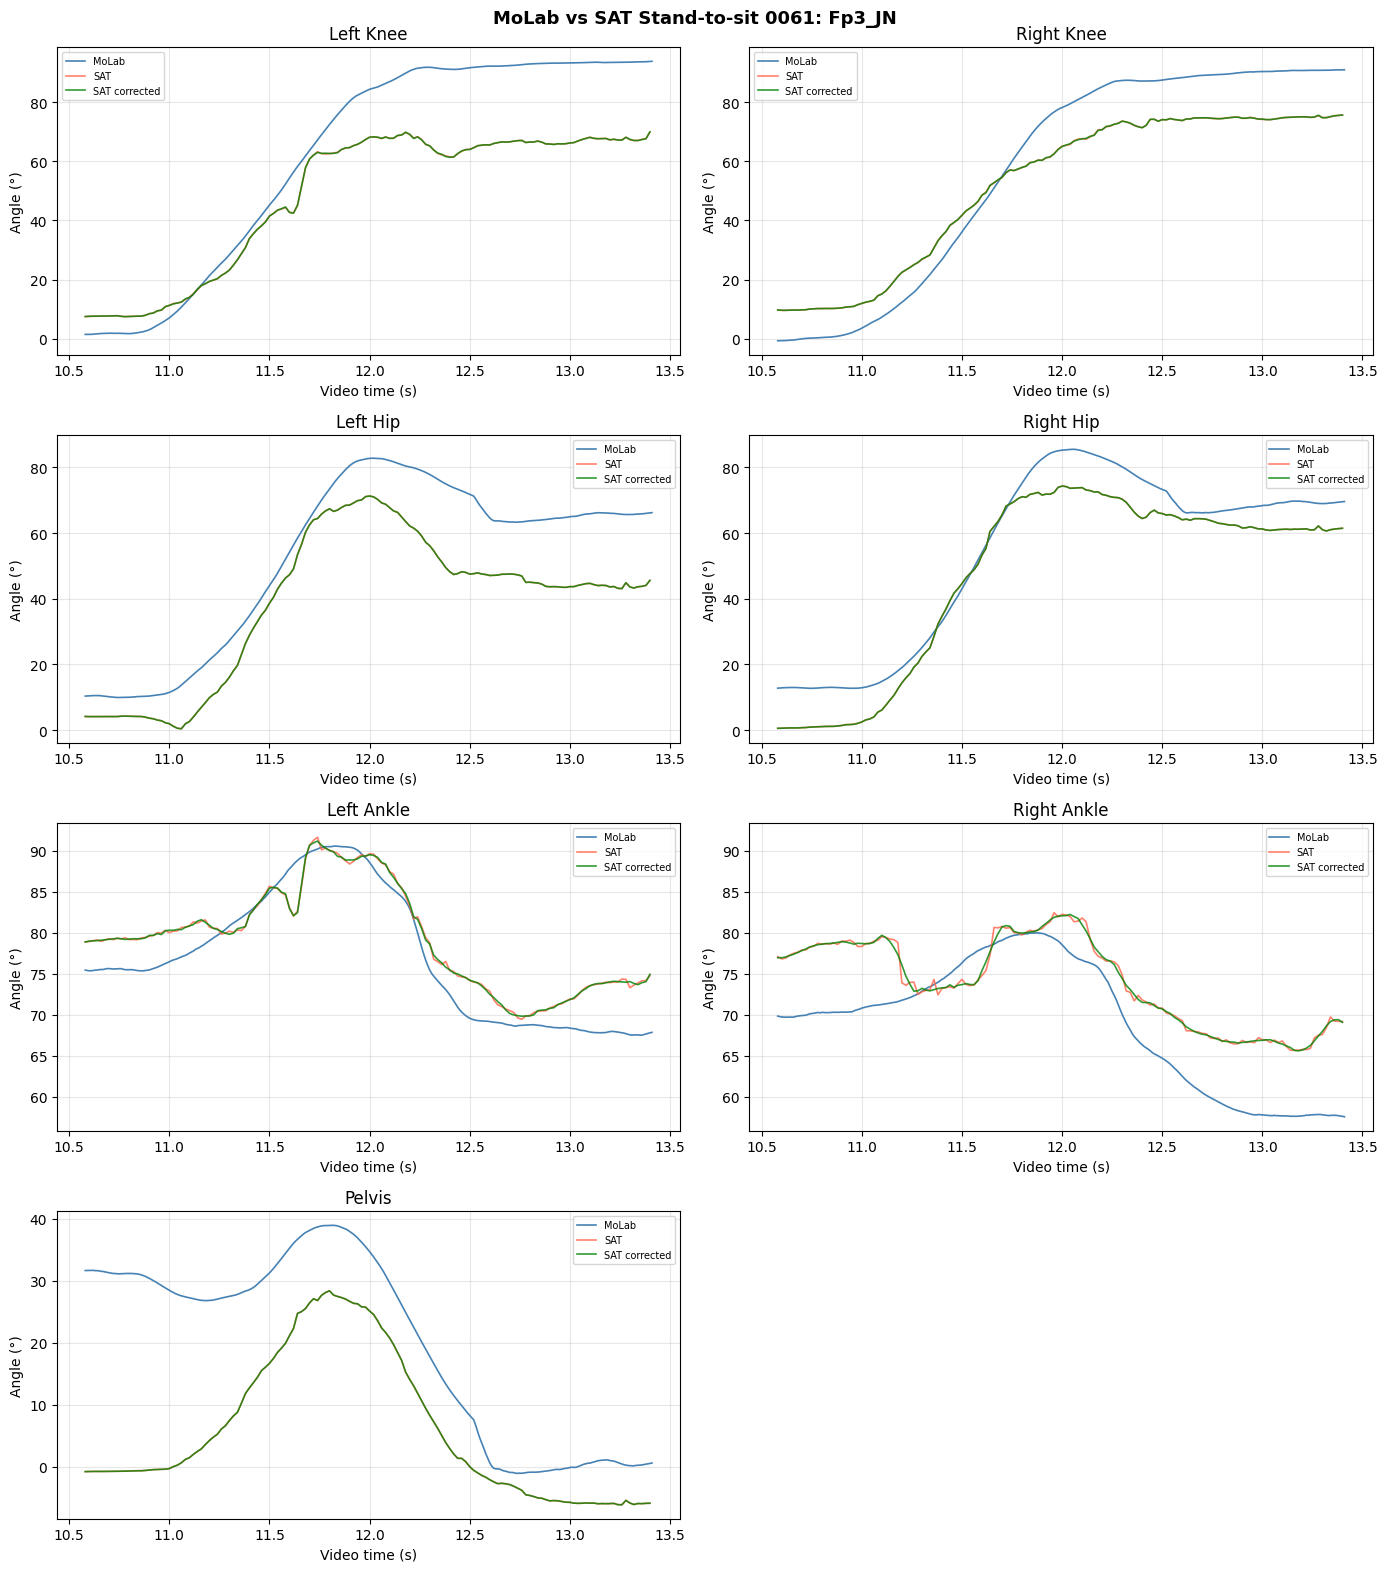

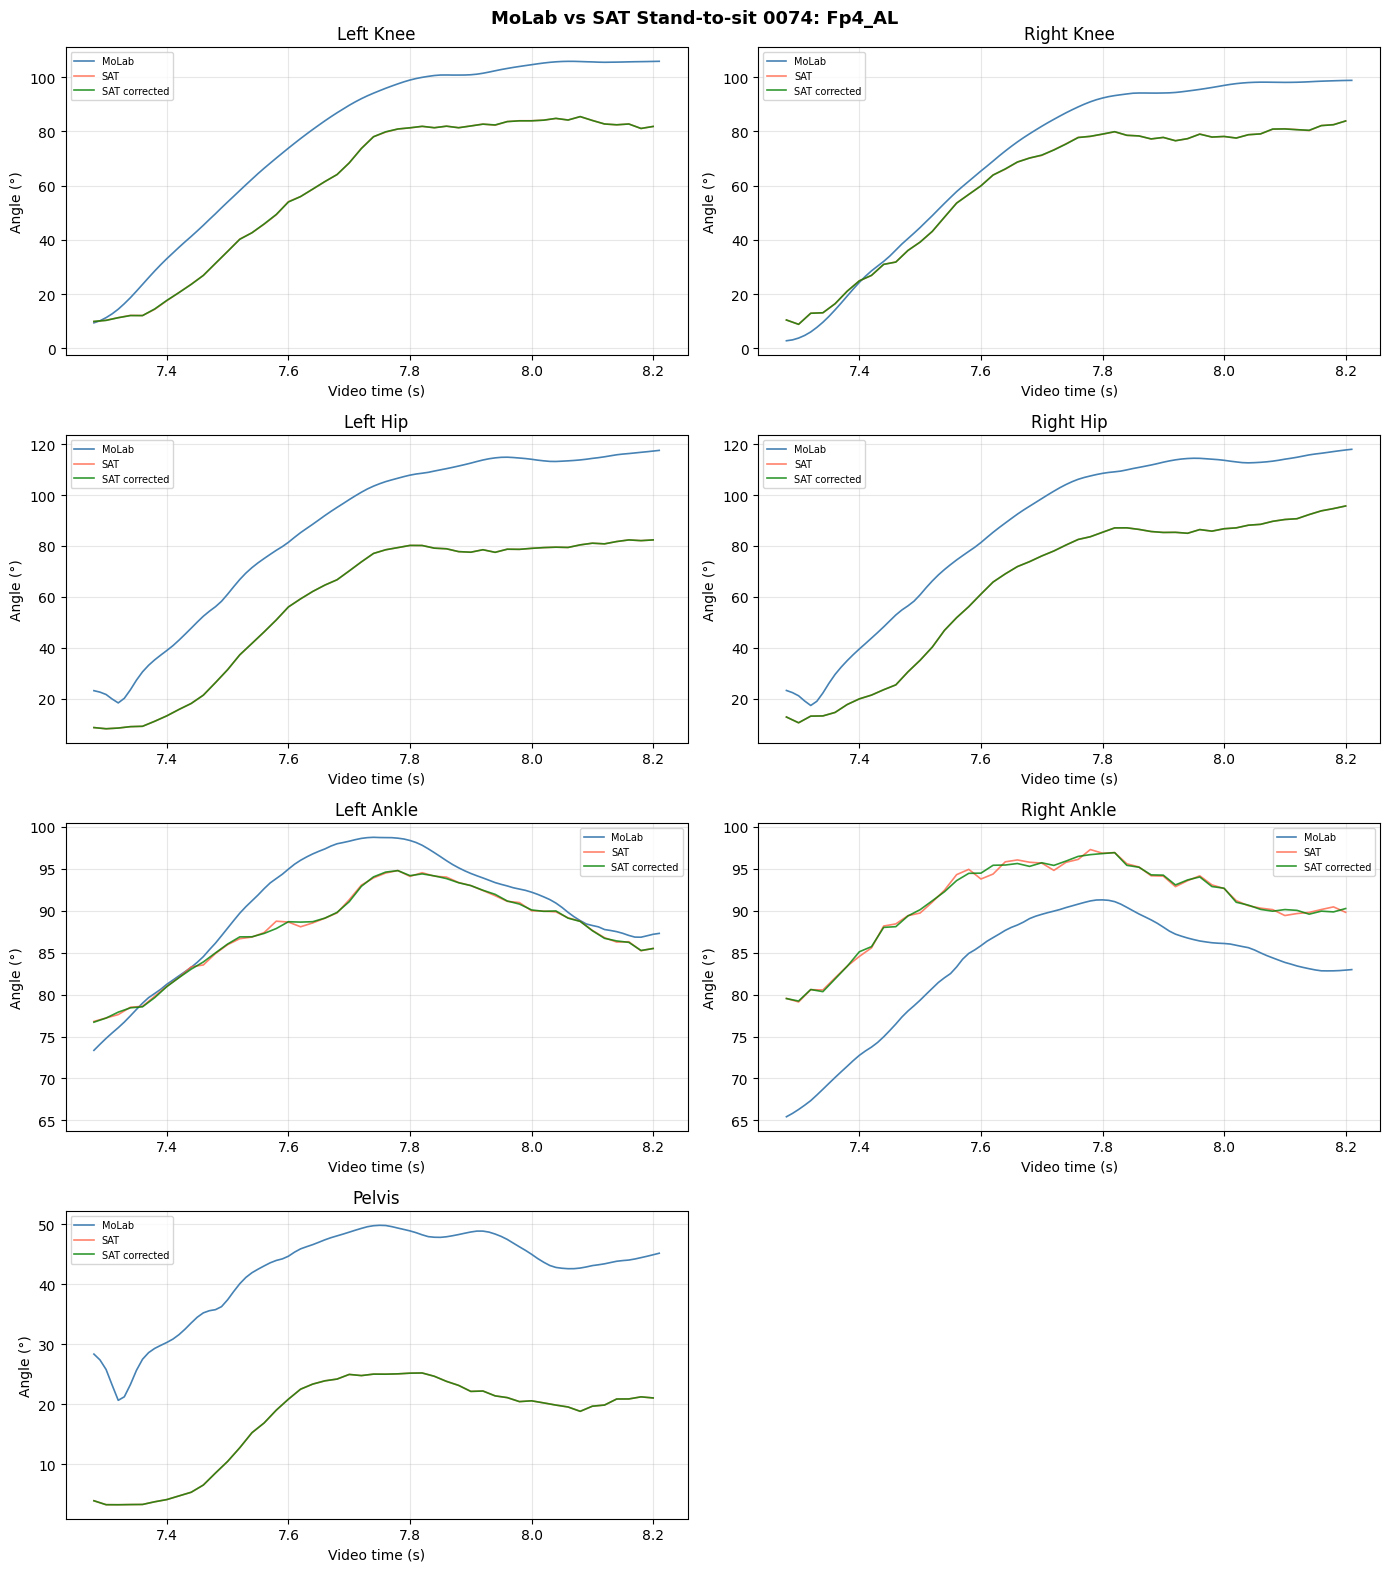

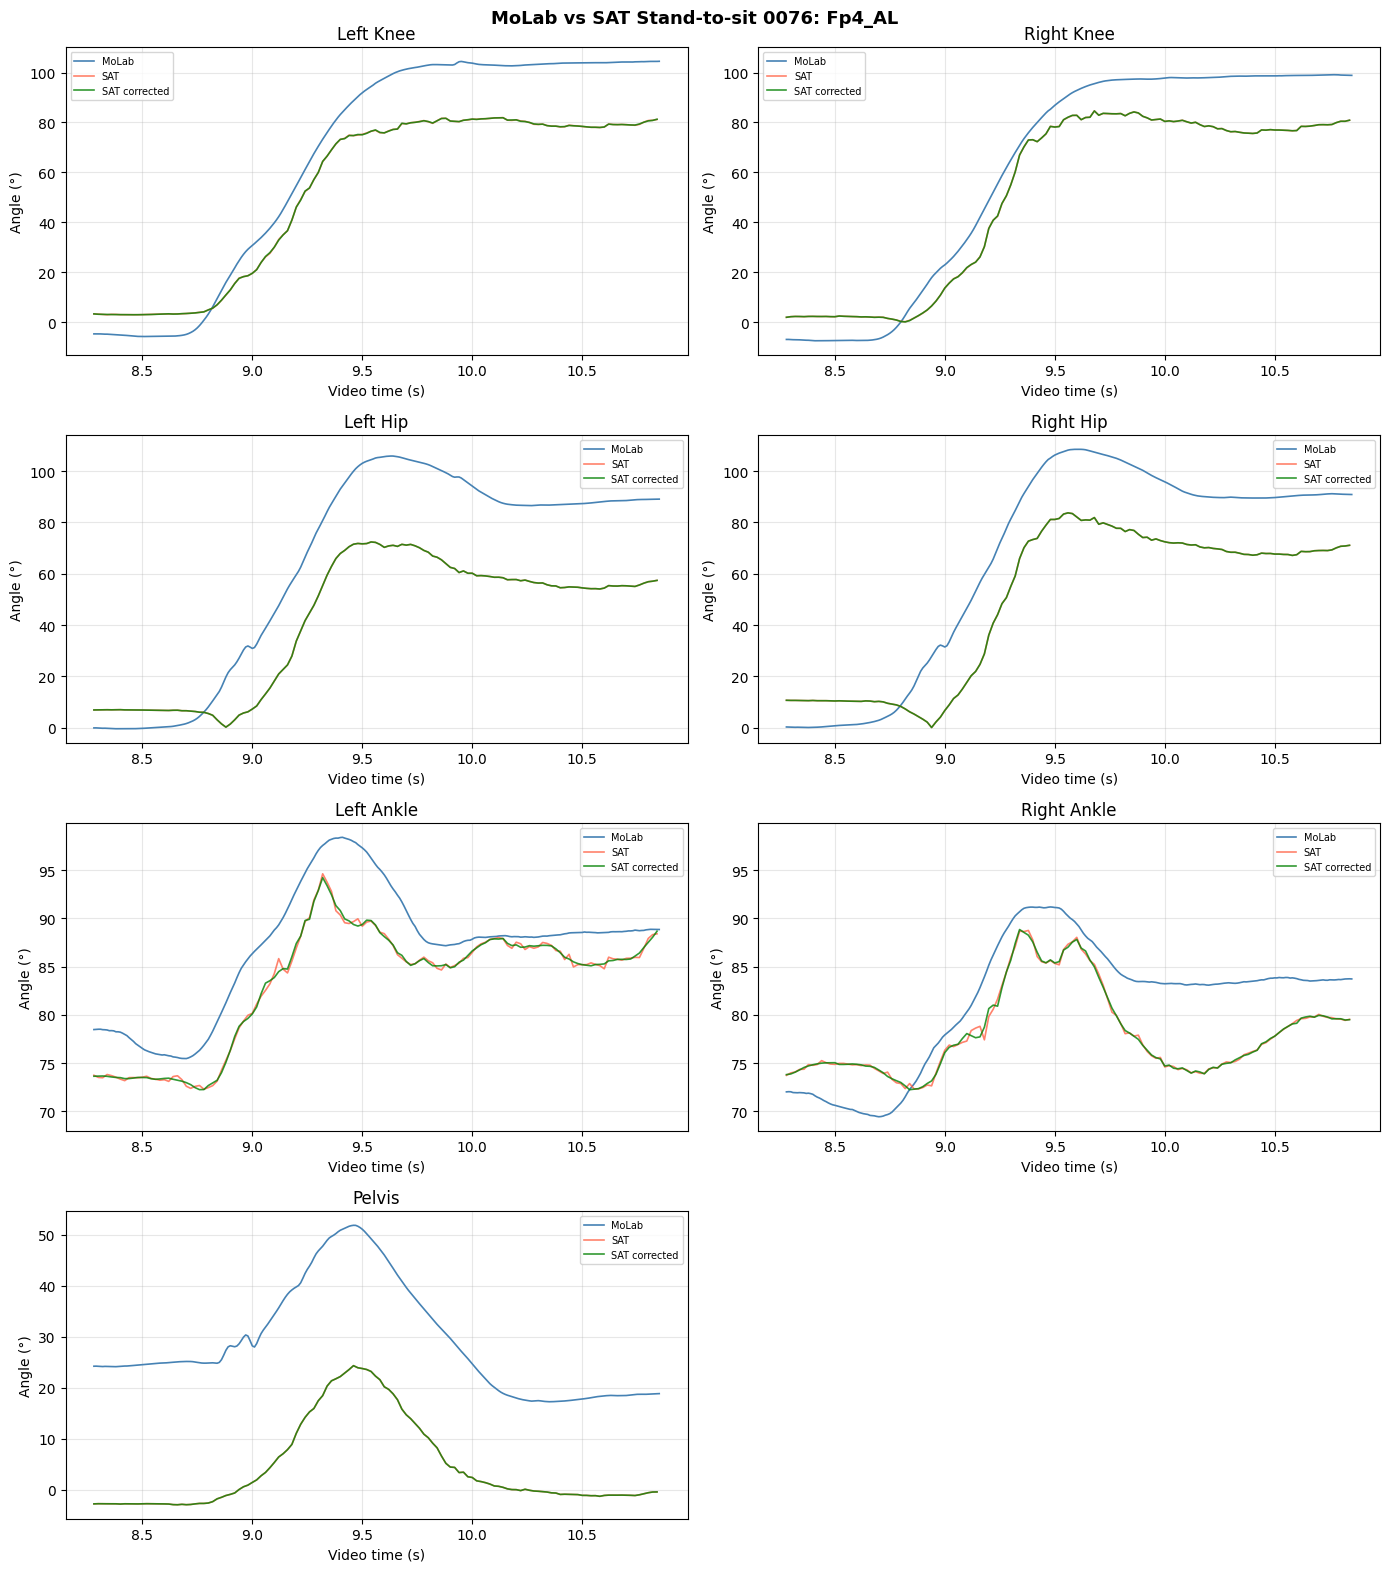

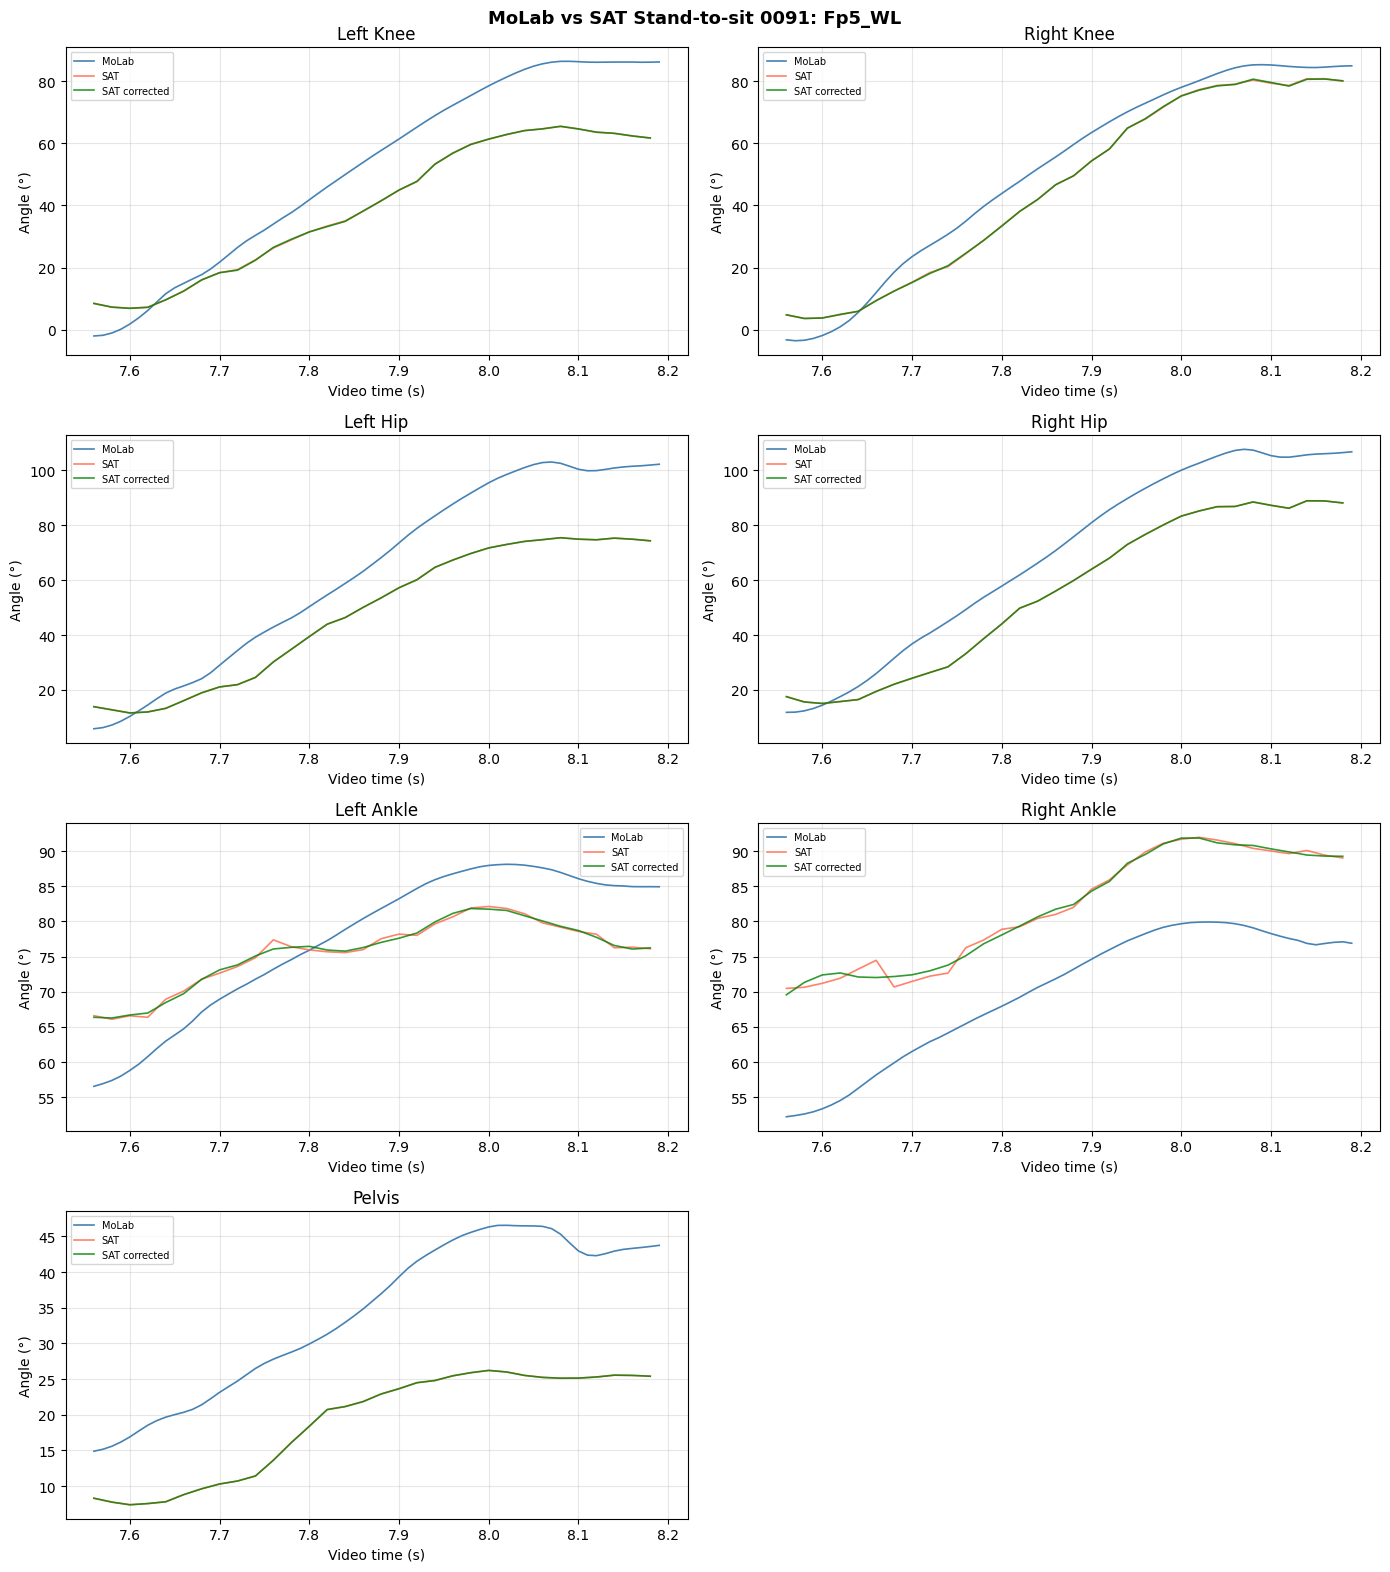

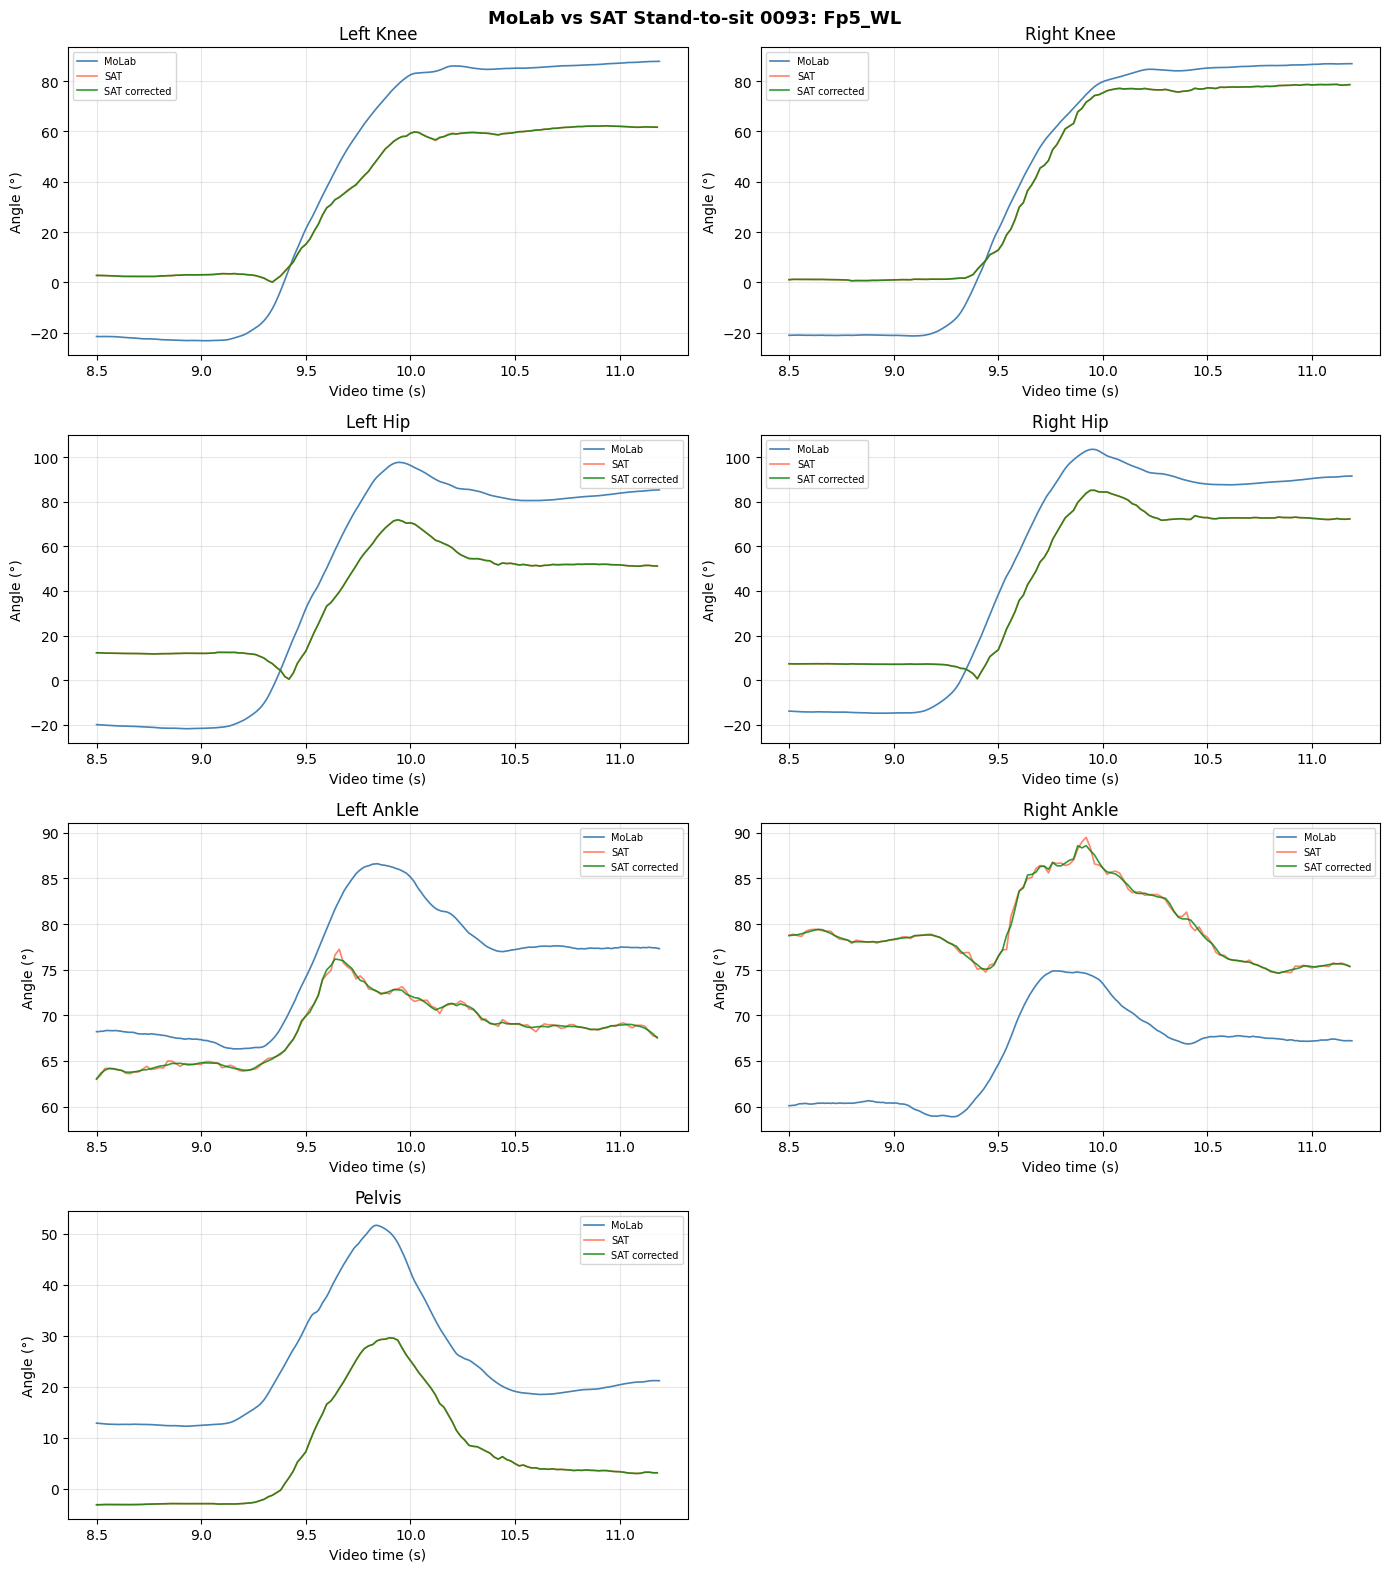

In [4]:
MOLAB_FS = 100
VIDEO_FPS = 50

mapping = [
    ('0028', 'Fp1_SB', '2c'),
    ('0030', 'Fp1_SB', '2e'),
    ('0045', 'Fp2_CF', '2c'),
    ('0047', 'Fp2_CF', '2e'),
    ('0059', 'Fp3_JN', '2c'),
    ('0061', 'Fp3_JN', '2e'),
    ('0074', 'Fp4_AL', '2c'),
    ('0076', 'Fp4_AL', '2e'),
    ('0091', 'Fp5_WL', '2c'),
    ('0093', 'Fp5_WL', '2e'),
]

beep_times = {
    '0028': 9.14,
    '0030': 5.38,
    '0045': 5.88,
    '0047': 6.12,
    '0059': 5.70,
    '0061': 6.10,
    '0074': 5.42,
    '0076': 5.54,
    '0091': 5.52,
    '0093': 5.00,
}

corrections = {
    '0028': 0.52,
}

MOLAB_FULL_DIR = '../data/processed/molab'
ANGLE_PLOTS_DIR = '../data/processed/angle_plots'
VIDEO_ASPECT = 1920 / 1080

PLOT_JOINTS = [
    ('L_knee_X',  'Left Knee'),
    ('R_knee_X',  'Right Knee'),
    ('L_hip_X',   'Left Hip'),
    ('R_hip_X',   'Right Hip'),
    ('L_ankle_X', 'Left Ankle'),
    ('R_ankle_X', 'Right Ankle'),
    ('pelvis_X',  'Pelvis'),
]

offsets = {}
for vid, fp, mid in mapping:
    full = pd.read_csv(f'{MOLAB_FULL_DIR}/{vid}_molab.csv')
    pre  = full[full['molab_frame'] < 41]
    offsets[vid] = {j: pre[f'JointAngle/{j}'].mean() for j, _ in PLOT_JOINTS}


def joint_angle_2d(ax, ay, bx, by, cx, cy):
    v1x, v1y = ax - bx, ay - by
    v2x, v2y = cx - bx, cy - by
    dot  = v1x * v2x + v1y * v2y
    norm = np.sqrt(v1x**2 + v1y**2) * np.sqrt(v2x**2 + v2y**2) + 1e-8
    return 180 - np.degrees(np.arccos(np.clip(dot / norm, -1, 1)))


def segment_angle_2d(ax, ay, bx, by, cx, cy, dx, dy):
    v1x, v1y = bx - ax, by - ay
    v2x, v2y = dx - cx, dy - cy
    dot  = v1x * v2x + v1y * v2y
    norm = np.sqrt(v1x**2 + v1y**2) * np.sqrt(v2x**2 + v2y**2) + 1e-8
    return 180 - np.degrees(np.arccos(np.clip(dot / norm, -1, 1)))


def trunk_angle_2d(kp):
    mid_hip_x = (kp['left_hip_x'] + kp['right_hip_x']) / 2
    mid_hip_y = (kp['left_hip_y'] + kp['right_hip_y']) / 2
    mid_sh_x  = (kp['left_shoulder_x'] + kp['right_shoulder_x']) / 2
    mid_sh_y  = (kp['left_shoulder_y'] + kp['right_shoulder_y']) / 2
    dx = mid_sh_x - mid_hip_x
    dy = mid_sh_y - mid_hip_y
    return -np.degrees(np.arctan2(dx, -dy))


def compute_kp_angles(kp):
    kp = kp.copy()
    x_cols = [c for c in kp.columns if c.endswith('_x')]
    kp[x_cols] *= VIDEO_ASPECT

    angles = {}
    for side, s in [('L', 'left'), ('R', 'right')]:
        angles[f'{side}_knee_X'] = joint_angle_2d(
            kp[f'{s}_hip_x'].values,    kp[f'{s}_hip_y'].values,
            kp[f'{s}_knee_x'].values,   kp[f'{s}_knee_y'].values,
            kp[f'{s}_ankle_x'].values,  kp[f'{s}_ankle_y'].values,
        )
        angles[f'{side}_hip_X'] = joint_angle_2d(
            kp[f'{s}_shoulder_x'].values, kp[f'{s}_shoulder_y'].values,
            kp[f'{s}_hip_x'].values,      kp[f'{s}_hip_y'].values,
            kp[f'{s}_knee_x'].values,     kp[f'{s}_knee_y'].values,
        )
        angles[f'{side}_ankle_X'] = segment_angle_2d(
            kp[f'{s}_heel_x'].values,       kp[f'{s}_heel_y'].values,
            kp[f'{s}_foot_index_x'].values, kp[f'{s}_foot_index_y'].values,
            kp[f'{s}_ankle_x'].values,      kp[f'{s}_ankle_y'].values,
            kp[f'{s}_knee_x'].values,       kp[f'{s}_knee_y'].values,
        )
    angles['pelvis_X'] = trunk_angle_2d(kp)
    return angles


def plot_molab_angles(molab_dir, kp_dir, kp_cor_dir, kp_pattern, title, out_dir, label):
    os.makedirs(out_dir, exist_ok=True)
    for vid, fp, mid in mapping:
        molab  = pd.read_csv(f'{molab_dir}/{vid}_molab.csv')
        offset = beep_times[vid] - 4 + corrections.get(vid, 0)
        t    = molab['molab_time'].values + offset
        mask = molab['molab_frame'].values >= 41

        kp_files  = glob.glob(f'{kp_dir}/{kp_pattern.format(vid=vid)}')
        kp_angles = None
        kp_time   = None
        if kp_files:
            kp        = pd.read_csv(kp_files[0])
            kp_time   = kp['frame'].values / VIDEO_FPS
            kp_angles = compute_kp_angles(kp)
        
        kp_cor_files  = glob.glob(f'{kp_cor_dir}/{kp_pattern.format(vid=vid)}')
        kp_cor_angles = None
        kp_cor_time   = None
        if kp_cor_files:
            kp_cor        = pd.read_csv(kp_cor_files[0])
            kp_cor_time   = kp_cor['frame'].values / VIDEO_FPS
            kp_cor_angles = compute_kp_angles(kp_cor)

        fig, axes = plt.subplots(4, 2, figsize=(14, 16))
        fig.suptitle(f'{title} {vid}: {fp}', fontsize=13, fontweight='bold')

        for row in range(3):
            axes[row, 1].sharey(axes[row, 0])

        for i, (joint, jlabel) in enumerate(PLOT_JOINTS):
            ax  = axes.flat[i]
            raw = molab[f'JointAngle/{joint}'].values.copy()
            raw[mask] += offsets[vid][joint]
            ax.plot(t, raw, linewidth=1.2, color='steelblue', label='MoLab')

            if kp_angles is not None and joint in kp_angles:
                ax.plot(kp_time, kp_angles[joint], linewidth=1.2,
                        color='tomato', alpha=0.8, label='SAT')

            if kp_cor_angles is not None and joint in kp_cor_angles:
                ax.plot(kp_cor_time, kp_cor_angles[joint], linewidth=1.2,
                        color='green', alpha=0.8, label='SAT corrected')
            
            ax.set_title(jlabel)
            ax.set_xlabel('Video time (s)')
            ax.set_ylabel('Angle (°)')
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=7)

        axes.flat[-1].set_visible(False)
        plt.tight_layout()
        plt.show()


plot_molab_angles(
    '../data/processed/molab_cropped',
    '../data/processed/keypoints_combined',
    '../data/processed/keypoints_corrected',
    'DJI_*_{vid}_D.csv',
    'MoLab vs SAT Sit-to-stand',
    f'{ANGLE_PLOTS_DIR}/sit_to_stand',
    'sit_to_stand',
)
plot_molab_angles(
    '../data/processed/molab_cropped_down',
    '../data/processed/keypoints_combined_down',
    '../data/processed/keypoints_corrected_down',
    'DJI_*_{vid}_D.csv',
    'MoLab vs SAT Stand-to-sit',
    f'{ANGLE_PLOTS_DIR}/stand_to_sit',
    'stand_to_sit',
)

## Save videos

In [5]:
import imageio
import re

VIDEO_DIR       = Path('../data/Utvalda filminspelningar för IRAF analys/Dec 2025 sit-stå och stå-sitt')

OUT_UP_DIR = Path('../data/processed/keypoints_corrected')
OUT_DOWN_DIR = Path('../data/processed/keypoints_corrected_down')

OUT_UP_VIDEOS = Path('../data/processed/keypoints_corrected_videos')
OUT_DOWN_VIDEOS = Path('../data/processed/keypoints_corrected_down_videos')

time_dict = {
    '028': (9.90,  11.77), '030': (5.80,  7.63),
    '045': (6.54,   7.98), '047': (7.03,  8.91),
    '059': (6.65,   9.11), '061': (6.00,  9.00),
    '074': (6.07,   7.27), '076': (5.00,  8.00),
    '091': (6.39,   7.61), '093': (5.86,  7.67),
}

stand_to_sit_time_dict = {
    '028': (11.87, 12.87), '030': (8.07,  11.56),
    '045': (7.94,   9.26), '047': (9.20,  12.30),
    '059': (9.11,  11.06), '061': (10.57, 13.41),
    '074': (7.27,   8.20), '076': (8.27,  10.84),
    '091': (7.56,   8.18), '093': (8.50,  11.19),
}

JOINTS = [
    'nose',
    'left_ear',
    'left_shoulder', 'right_shoulder',
    'left_elbow',    'right_elbow',
    'left_wrist',    'right_wrist',
    'left_hip',      'right_hip',
    'left_knee',     'right_knee',
    'left_ankle',    'right_ankle',
]

MEDIAPIPE_EXTRA_JOINTS = [
    'left_heel',       'right_heel',
    'left_foot_index', 'right_foot_index',
]

ALL_JOINTS = JOINTS + MEDIAPIPE_EXTRA_JOINTS

COLOR_MEDIAPIPE = (255, 80,  80)
COLOR_MOVENET   = (80,  200, 80)
COLOR_GPR       = (0,   165, 255)

def draw_keypoints_on_image(image, row):
    height, width, _ = image.shape
    dpi = 100
    fig, ax = plt.subplots(figsize=(width / dpi, height / dpi), dpi=dpi)
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
    ax.margins(0)
    ax.axis('off')
    ax.imshow(image)

    for joint in ALL_JOINTS:
        x = row.get(f'{joint}_x')
        y = row.get(f'{joint}_y')
        if pd.isna(x) or pd.isna(y):
            continue
        src = row.get(f'{joint}_source', 'mediapipe')
        if src == 'movenet':
            color = '#50c850'
        elif src == 'gpr':
            color = '#ffa500'
        else:
            color = '#5050ff'
        ax.scatter([x * width], [y * height], c=color, s=50)

    fig.canvas.draw()
    buf = np.frombuffer(fig.canvas.tostring_argb(), dtype=np.uint8)
    buf = buf.reshape(fig.canvas.get_width_height()[::-1] + (4,))
    img = buf[:, :, 1:4]
    plt.close(fig)
    return img


for out_csv, out_video, td, label in [
    (OUT_UP_DIR, OUT_UP_VIDEOS, time_dict, 'sit-to-stand'),
    (OUT_DOWN_DIR, OUT_DOWN_VIDEOS, stand_to_sit_time_dict, 'stand-to-sit'),
]:
    out_video.mkdir(parents=True, exist_ok=True)
    print(f'\n=== {label} ===')
    for csv_path in sorted(out_csv.glob('*.csv')):
        match = re.search(r'_0(\d{3})_D', csv_path.stem)
        if not match:
            continue
        vid_id    = match.group(1)
        vid_files = list(VIDEO_DIR.glob(f'*_0{vid_id}_D.MP4'))

        if not vid_files:
            print(f'Video not found: {vid_id}')
            continue

        df          = pd.read_csv(csv_path)
        out_path    = out_video / f'{csv_path.stem}.mp4'
        start_frame = int(td[vid_id][0] * VIDEO_FPS)
        reader      = imageio.get_reader(str(vid_files[0]))

        with imageio.get_writer(str(out_path), fps=VIDEO_FPS) as writer:
            for i, row in df.iterrows():
                frame = reader.get_data(start_frame + i)
                writer.append_data(draw_keypoints_on_image(frame, row))

        reader.close()
        print(f'{vid_id}: saved -> {out_path.name}')


=== stand-to-sit ===


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1920, 1080) to (1920, 1088) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


028: saved -> DJI_20250425092743_0028_D.mp4


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1920, 1080) to (1920, 1088) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


030: saved -> DJI_20250425093100_0030_D.mp4


...

076: saved -> DJI_20250425121226_0076_D.mp4


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1920, 1080) to (1920, 1088) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


091: saved -> DJI_20250425125202_0091_D.mp4


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1920, 1080) to (1920, 1088) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


093: saved -> DJI_20250425125448_0093_D.mp4
